# Anomaly Investigation — Why Do Predictions Land Two or Three CGPA Bands Away?

**CSE-4112 Machine Learning Laboratory** · follows `02_merged_cleaning_eda_modeling.ipynb`

### What the teacher saw

In the team's WEKA confusion matrices, most errors sit next to the diagonal (C1 predicted as C0
or C2) — which is reasonable for ordered bands — but a **significant number sit two or three
bands away**. A C0 student (CGPA below 3.20) predicted as C3 (3.75 and above) is not a near miss;
it means the model had no idea. The teacher asked us to find out *why*, and set seven checks:

| # | Teacher's check | Section |
|---|---|---|
| 1 | Re-read our presentation and its numbers | §3 |
| 4 | Is some data filled randomly, "just to fill the form"? Too many prodigies at KUET? | §4 |
| 5 | Check KUET only and 4th semester only — is the low accuracy everywhere or local? | §5 |
| 2 | Try 5-fold CV and train/test splits — does that change anything? | §6 |
| 3 | Give the features different weights — does that change anything, and why? | §7 |
| 6 | Do the three decision trees mean anything, or are they random? | §8 |
| 7 | Propose fixes, justify them, and verify them with results | §9–§11 |

The checks are answered in the order the evidence builds, not in the teacher's numbering: once
§4 finds the cause, every later check can be read in its light.

### How this notebook is built

**Every model number here is produced by WEKA 3.8.7**, called from Python through
`notebooks/weka_runner.py`. Each run's raw WEKA output is saved to `docs/weka_runs/<name>.txt`
with the exact command on its first line, so any number can be re-checked in the WEKA Explorer.
Python is used only for three things: preparing ARFF files, computing quality flags on the raw
answers, and turning WEKA's confusion matrices into charts.

Throughout, a **far error** means a prediction two or more bands from the truth
(`|actual − predicted| ≥ 2`). It is the quantity the teacher is asking about.

## 1. Setup

In [1]:
import warnings, json, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
import sys
sys.path.insert(0, str(ROOT / "notebooks"))
import weka_runner as W

FIG_DIR = ROOT / "docs" / "figures" / "anomaly"
FIG_DIR.mkdir(parents=True, exist_ok=True)
W.ARFF_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 140, "savefig.bbox": "tight",
                     "axes.titleweight": "bold"})
PALETTE = ["#3E7CB1", "#E8A33D", "#5FA55A", "#C4554D", "#8A6FA8", "#7A7A7A"]
BANDS = ["C0", "C1", "C2", "C3"]
BAND_RANGE = {"C0": "<3.20", "C1": "3.20-3.49", "C2": "3.50-3.74", "C3": "3.75+"}

def save_fig(name):
    plt.savefig(FIG_DIR / f"{name}.png")
    plt.show()

def cm_plot(ax, cm, title, far_highlight=True):
    """Confusion matrix with far-error cells (>= 2 bands off) outlined in red."""
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=BANDS, yticklabels=BANDS, annot_kws={"fontsize": 11})
    if far_highlight:
        for i in range(4):
            for j in range(4):
                if abs(i - j) >= 2:
                    ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, ec=PALETTE[3], lw=2.2))
    ax.set_xlabel("predicted"); ax.set_ylabel("actual"); ax.set_title(title, fontsize=10)

ver = __import__("subprocess").run([str(W.JAVA), "-cp", str(W.WEKA_JAR), "weka.core.Version"],
                                   capture_output=True, text=True).stdout.splitlines()[0]
print("WEKA version:", ver)
print("java        :", W.JAVA)
print("raw logs    :", W.RUN_DIR)

WEKA version: 3.8.7
java        : C:\Program Files\Weka-3-8-7\jre\jre-25.0.2-full\bin\java.exe
raw logs    : E:\4-1\ml-lab\docs\weka_runs


## 2. Rebuild the exact dataset the team ran in WEKA

The deck reports **N = 1,102**. Notebook `02` produced 1,108 clean rows; the 6-row difference is
exactly the rows whose recent SGPA had to be imputed (§5.8 of notebook `02`). Using the real
answer only is the right call for these experiments, because recent SGPA is the strongest
feature and an imputed value would blur precisely the relationship we are about to audit.

The cleaned file has no timestamps (notebook `02` drops them as a modelling feature, correctly).
For *auditing* we need them back, so we re-attach them from the raw exports and **assert** that
the target and the recent SGPA line up row for row — if a single row were misaligned, the
assertion would stop the notebook.

In [2]:
clean = pd.read_csv(ROOT / "cleaned-dataset" / "ours" / "merged" / "merged_full_clean.csv")
raw_multi = pd.read_csv(ROOT / "raw-data" / "University Student Performance Analysis Form (Responses) - Form Responses 1.csv")
raw_kuet = pd.read_csv(ROOT / "raw-data" / "Student Performance Analysis Form (Responses) - Form Responses 1.csv")

BAND_CODE = {"Below": 0, "3.0+": 0, "3.2+": 1, "3.5+": 2, "3.75+": 3, "3.9+": 3,
             "3.20 - 3.49": 1, "3.2 - 3.49": 1, "3.20-3.49": 1, "3.2-3.49": 1,
             "3.50 - 3.74": 2, "3.50-3.74": 2, "3.5 - 3.74": 2}

def band_code(v):
    """Same parsing rule as notebook 02: band label, or a typed number binned by the cut-points."""
    if not isinstance(v, str):
        return np.nan
    s = " ".join(v.split(" (")[0].split())
    if s in BAND_CODE:
        return BAND_CODE[s]
    try:
        x = float(s)
        if 0 <= x <= 4:
            return 0 if x < 3.2 else 1 if x < 3.5 else 2 if x < 3.75 else 3
    except ValueError:
        pass
    return np.nan

# column positions in each raw export: timestamp, recent SGPA, CGPA
stamp = pd.concat([
    pd.DataFrame({"ts": raw_multi.iloc[:, 0], "cg": raw_multi.iloc[:, 8].map(band_code),
                  "sg": raw_multi.iloc[:, 7].map(band_code)}),
    pd.DataFrame({"ts": raw_kuet.iloc[:, 0], "cg": raw_kuet.iloc[:, 4].map(band_code),
                  "sg": raw_kuet.iloc[:, 3].map(band_code)}),
], ignore_index=True)
stamp = stamp[stamp.cg.notna()].reset_index(drop=True)          # notebook 02, step 5.6
assert len(stamp) == len(clean)
assert (stamp.cg.values == clean.target_code.values).all(), "target misaligned"

keep = ~clean.recent_sgpa_imputed.values
df = clean[keep].reset_index(drop=True)
stamp = stamp[keep].reset_index(drop=True)
assert (stamp.sg.values == df.recent_sgpa_code.values).all(), "recent SGPA misaligned"
df["ts"] = pd.to_datetime(stamp.ts, format="mixed")
df["date"] = df.ts.dt.strftime("%Y-%m-%d")

ITEMS = ["desired_department_match", "attendance", "weekly_study_time", "study_style", "topic_clarity",
         "sleep_duration", "stress_frequency", "weekly_responsibilities", "distraction_frequency",
         "study_environment", "support_level", "routine_manageability"]
df["gap"] = (df.recent_sgpa_code - df.target_code).abs()
df["far_gap"] = df.gap >= 2

print(f"rows: {len(df)}  (1,108 clean - {int((~keep).sum())} with imputed recent SGPA)")
print("alignment of target and recent SGPA with the raw exports: verified")
print(df.source_form.value_counts().to_string())

rows: 1102  (1,108 clean - 6 with imputed recent SGPA)
alignment of target and recent SGPA with the raw exports: verified
source_form
kuet         872
multi_uni    230


**The 12 questionnaire features** are the ones on the team's slides (the WEKA attribute list):
desired department match, attendance, weekly study time, study style, topic clarity, sleep,
stress, outside commitments, phone distraction, study environment, support and routine. The
"main CGPA" model adds **recent SGPA band** as a 13th input.

In [3]:
def weka_frame(frame, target="cgpa", with_sgpa=True, sgpa_numeric=False, extra=None):
    """Build the WEKA attribute table: 12 ordinal items (numeric codes 0-4), optional recent SGPA,
    optional extra columns, and the class last."""
    out = pd.DataFrame({i: frame[i + "_code"].astype(int).values for i in ITEMS})
    nominal = {}
    if with_sgpa:
        if sgpa_numeric:
            out["recent_sgpa"] = frame.recent_sgpa_code.astype(int).values
        else:
            out["recent_sgpa_band"] = ["C%d" % v for v in frame.recent_sgpa_code]
            nominal["recent_sgpa_band"] = BANDS
    for col, (vals, levels) in (extra or {}).items():
        out[col] = list(vals)
        if levels is not None:
            nominal[col] = levels
    cls = "sgpa_band" if target == "sgpa" else "cgpa_band"
    out[cls] = ["C%d" % v for v in (frame.recent_sgpa_code if target == "sgpa" else frame.target_code)]
    nominal[cls] = BANDS
    return out, nominal, cls

def make_arff(frame, name, **kw):
    table, nominal, cls = weka_frame(frame, **kw)
    return W.write_arff(table, W.ARFF_DIR / f"{name}.arff", Path(name).name, nominal, class_col=cls)

MAIN = make_arff(df, "main_cgpa_1102")                               # 12 items + recent SGPA -> CGPA
QUEST = make_arff(df, "questionnaire_cgpa_1102", with_sgpa=False)     # 12 items -> CGPA
SGPA_T = make_arff(df, "questionnaire_sgpa_1102", target="sgpa", with_sgpa=False)   # 12 items -> SGPA
print("\n".join(str(p.relative_to(ROOT)) for p in (MAIN, QUEST, SGPA_T)))

cleaned-dataset\ours\anomaly\main_cgpa_1102.arff
cleaned-dataset\ours\anomaly\questionnaire_cgpa_1102.arff
cleaned-dataset\ours\anomaly\questionnaire_sgpa_1102.arff


## 3. Check 1 — reproduce the anomaly from the team's own setting

Before explaining an anomaly, reproduce it. We run the team's main-CGPA setting — 12 items plus
recent SGPA, stratified 10-fold CV, seed 1 — through WEKA's Random Forest and SMO.

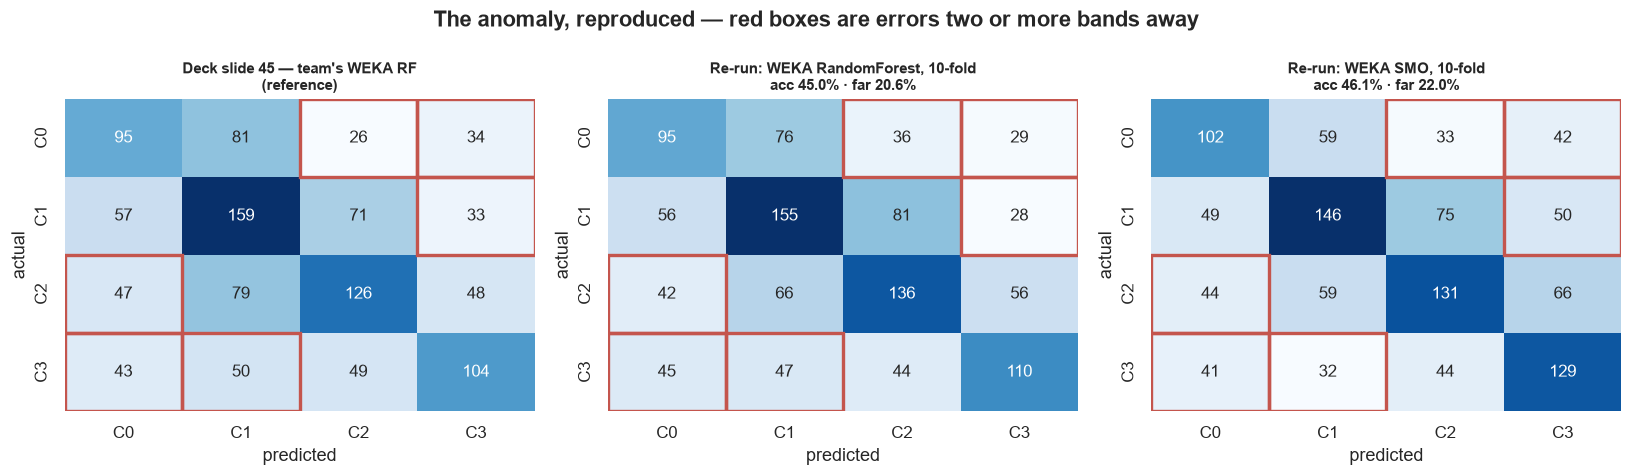

deck RF   : acc 43.9% | far-error rate 21.1%
A_main_RandomForest_cv10  : acc 45.0% | kappa 0.261 | QWK 0.320 | far 20.6%
A_main_SMO_cv10           : acc 46.1% | kappa 0.279 | QWK 0.322 | far 22.0%
A_main_ZeroR_cv10         : acc 29.0% | kappa 0.000 | QWK 0.000 | far 22.3%


In [4]:
base_rf = W.run("A_main_RandomForest_cv10", W.RF, MAIN)
base_smo = W.run("A_main_SMO_cv10", W.SMO, MAIN)
base_zr = W.run("A_main_ZeroR_cv10", W.ZEROR, MAIN)

deck_rf = np.array([[95, 81, 26, 34], [57, 159, 71, 33], [47, 79, 126, 48], [43, 50, 49, 104]])
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
cm_plot(axes[0], deck_rf, "Deck slide 45 — team's WEKA RF\n(reference)")
cm_plot(axes[1], base_rf.cm, f"Re-run: WEKA RandomForest, 10-fold\nacc {base_rf.accuracy:.1%} · far {base_rf.far_rate:.1%}")
cm_plot(axes[2], base_smo.cm, f"Re-run: WEKA SMO, 10-fold\nacc {base_smo.accuracy:.1%} · far {base_smo.far_rate:.1%}")
plt.suptitle("The anomaly, reproduced — red boxes are errors two or more bands away", fontweight="bold")
plt.tight_layout()
save_fig("a01_anomaly_reproduced")

deck_far = deck_rf[np.abs(np.subtract.outer(range(4), range(4))) >= 2].sum() / deck_rf.sum()
print(f"deck RF   : acc {np.trace(deck_rf)/deck_rf.sum():.1%} | far-error rate {deck_far:.1%}")
for r in (base_rf, base_smo, base_zr):
    print(f"{r.name:<26}: acc {r.accuracy:.1%} | kappa {r.kappa:.3f} | QWK {r.qwk:.3f} | far {r.far_rate:.1%}")

**Reproduced.** Our WEKA run lands within a point or two of the deck (Random Forest is seeded
internally, so its exact count moves slightly between configurations), and about **one
prediction in five is two or more bands wrong**.

> **A consistency note on the deck itself.** The deck quotes two different WEKA Random Forest
> accuracies for the same main-CGPA task: **43.92%** (slide 36/48, matching the slide-45 matrix)
> and **46.3%** (slides 54/63). Both are plausible single runs of a randomised model; they should
> not appear side by side as if they were one result. §6 shows how much a single number moves
> from run to run, and the report recommends quoting one canonical run with its spread.

### 3.1 Where do the far errors actually land?

A confusion matrix says *how many* far errors there are, not *whose*. To find out, we ask WEKA
for its per-student cross-validation predictions. The trick is standard WEKA practice: add a row
ID as the first attribute, remove it inside `FilteredClassifier` so the model never sees it, and
print it back next to each prediction.

far errors                                    : 227
  ...on students whose OWN SGPA and CGPA differ by >= 2 bands: 69.2%
those students are 22.0% of the data
accuracy on students with SGPA/CGPA within 1 band : 55.5%
accuracy on students with SGPA/CGPA >= 2 bands apart: 11.2%


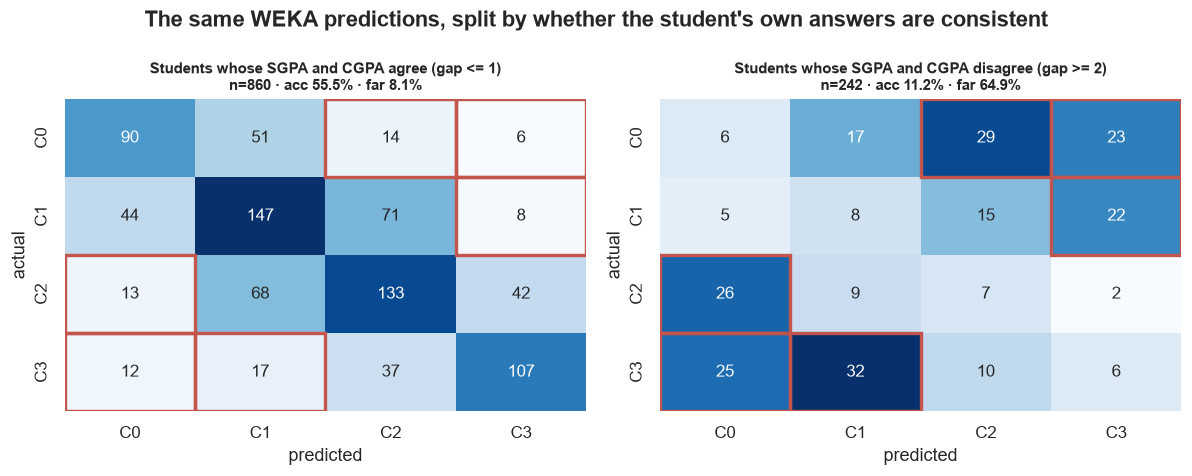

In [5]:
table, nominal, cls = weka_frame(df)
table.insert(0, "row_id", np.arange(len(df)))
ID_MAIN = W.write_arff(table, W.ARFF_DIR / "main_cgpa_1102_with_id.arff", "main_cgpa_1102_with_id", nominal)
pred = W.run_predictions("A_main_RandomForest_cv10_predictions",
                         ["weka.classifiers.meta.FilteredClassifier",
                          "-F", "weka.filters.unsupervised.attribute.Remove -R 1",
                          "-W", "weka.classifiers.trees.RandomForest"],
                         ID_MAIN, base=W.RF[1:])
pred = pred.merge(df[["gap", "far_gap", "source_form", "semester_raw"]], left_on="row_id", right_index=True)
pred["far_error"] = (pred.actual - pred.predicted).abs() >= 2

share = pred.loc[pred.far_error, "far_gap"].mean()
acc_consistent = (pred.loc[~pred.far_gap, "actual"] == pred.loc[~pred.far_gap, "predicted"]).mean()
acc_contra = (pred.loc[pred.far_gap, "actual"] == pred.loc[pred.far_gap, "predicted"]).mean()
print(f"far errors                                    : {pred.far_error.sum()}")
print(f"  ...on students whose OWN SGPA and CGPA differ by >= 2 bands: {share:.1%}")
print(f"those students are {pred.far_gap.mean():.1%} of the data")
print(f"accuracy on students with SGPA/CGPA within 1 band : {acc_consistent:.1%}")
print(f"accuracy on students with SGPA/CGPA >= 2 bands apart: {acc_contra:.1%}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, mask, title in [(axes[0], ~pred.far_gap, "Students whose SGPA and CGPA agree (gap <= 1)"),
                        (axes[1], pred.far_gap, "Students whose SGPA and CGPA disagree (gap >= 2)")]:
    sub = pred[mask]
    cm = pd.crosstab(sub.actual, sub.predicted).reindex(index=range(4), columns=range(4), fill_value=0).values
    cm_plot(ax, cm, f"{title}\nn={len(sub)} · acc {np.trace(cm)/cm.sum():.1%} · far {W.WekaResult('x', cm, '', '').far_rate:.1%}")
plt.suptitle("The same WEKA predictions, split by whether the student's own answers are consistent", fontweight="bold")
plt.tight_layout()
save_fig("a02_far_errors_by_consistency")

**This is the heart of the anomaly.** Roughly two thirds of all far errors fall on the ~22% of
students whose *own* recent SGPA and CGPA are two or three bands apart. On everyone else the same
WEKA model is far better, and its errors look the way the teacher expects — mostly next to the
diagonal.

Why this produces far errors specifically: recent SGPA is by far the strongest input, so the model
learns "CGPA band ≈ SGPA band". A student who reports SGPA **C3** and CGPA **C0** is then predicted
near C3 — three bands off — *because the model is doing the sensible thing with an answer that
contradicts itself*. The question is whether those contradictions are real students or bad data.

## 4. Check 4 — was some of the form filled randomly?

A student's last semester SGPA and their cumulative CGPA are **the same kind of number measured
over different windows**, so they must be strongly related. We use that relationship as a
built-in lie detector, and then look for independent evidence that does not use the CGPA at all.

### 4.1 SGPA vs CGPA, cohort by cohort

,n,SGPA-CGPA Spearman rho,observed far-gap rate,3-band gap rate,far-gap rate if answered at random
cohort,,,,,
KUET sem 1-6,197,0.882,0.030,0.000,0.361
KUET sem 7,675,0.107,0.295,0.093,0.342
Multi-uni sem 1-4,29,-0.069,0.448,0.276,0.439
Multi-uni sem 5+,201,0.528,0.119,0.060,0.353


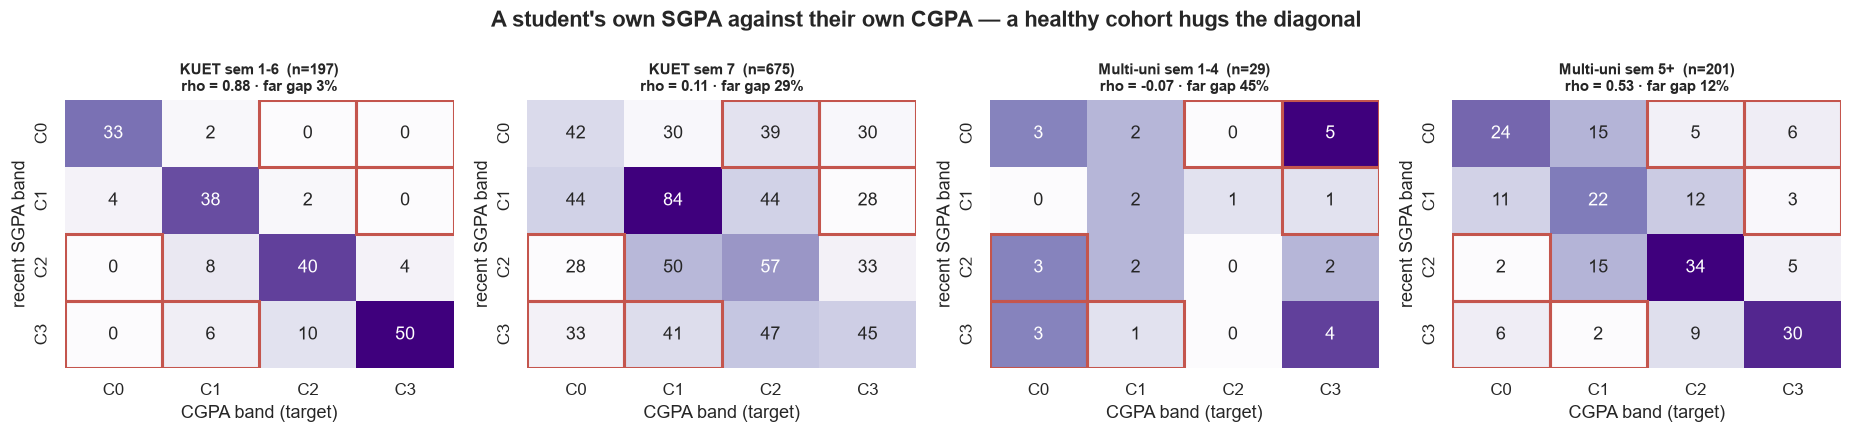

In [6]:
def cohort(r):
    if r.source_form == "kuet":
        return "KUET sem 7" if r.semester_raw == 7 else "KUET sem 1-6"
    return "Multi-uni sem 5+" if r.semester_raw >= 5 else "Multi-uni sem 1-4"
df["cohort"] = df.apply(cohort, axis=1)
COHORTS = ["KUET sem 1-6", "KUET sem 7", "Multi-uni sem 1-4", "Multi-uni sem 5+"]

def far_if_independent(sub):
    """Far-gap rate we would see if SGPA and CGPA were chosen independently (random filling)
    with the cohort's own answer frequencies."""
    ps = sub.recent_sgpa_code.value_counts(normalize=True).reindex(range(4), fill_value=0).values
    pt = sub.target_code.value_counts(normalize=True).reindex(range(4), fill_value=0).values
    return sum(ps[i] * pt[j] for i in range(4) for j in range(4) if abs(i - j) >= 2)

coh = pd.DataFrame([{
    "cohort": g, "n": len(s),
    "SGPA-CGPA Spearman rho": s[["recent_sgpa_code", "target_code"]].corr("spearman").iloc[0, 1],
    "observed far-gap rate": s.far_gap.mean(),
    "3-band gap rate": (s.gap == 3).mean(),
    "far-gap rate if answered at random": far_if_independent(s),
} for g, s in df.groupby("cohort")]).set_index("cohort").reindex(COHORTS)
display(coh.round(3))

fig, axes = plt.subplots(1, 4, figsize=(17, 4))
for ax, g in zip(axes, COHORTS):
    s = df[df.cohort == g]
    cm = pd.crosstab(s.recent_sgpa_code, s.target_code).reindex(index=range(4), columns=range(4), fill_value=0)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", cbar=False, ax=ax, xticklabels=BANDS, yticklabels=BANDS)
    for i in range(4):
        for j in range(4):
            if abs(i - j) >= 2:
                ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, ec=PALETTE[3], lw=2))
    ax.set_xlabel("CGPA band (target)"); ax.set_ylabel("recent SGPA band")
    ax.set_title(f"{g}  (n={len(s)})\nrho = {coh.loc[g, 'SGPA-CGPA Spearman rho']:.2f} · far gap {coh.loc[g, 'observed far-gap rate']:.0%}", fontsize=10)
plt.suptitle("A student's own SGPA against their own CGPA — a healthy cohort hugs the diagonal", fontweight="bold")
plt.tight_layout()
save_fig("a03_sgpa_vs_cgpa_by_cohort")

**KUET semester 7 is not like any other cohort.**

- In KUET semesters 1–6 the SGPA–CGPA correlation is about **0.88** and a two-band gap almost
  never happens (~3%).
- In KUET semester 7 the correlation collapses to about **0.11** and **~30%** of students report a
  gap of two or more bands — close to the ~34% we would expect if the two answers had been picked
  independently at random.

That is the opposite of what arithmetic predicts. By semester 7, CGPA averages six or seven
semesters, so a single SGPA should move it *less*, not more. A genuine seventh-semester student
with a last SGPA below 3.20 and a CGPA of 3.75+ needs roughly a 3.84 average over every earlier
semester — possible for one student, not for one in ten.

The multi-university sample is mixed: BRAC and CUET show no far gaps at all, while BUET shows
about a third, so the problem is not *only* KUET — but KUET semester 7 is where the volume is.

### 4.2 When did the contradictory answers arrive?

If careless answers were spread evenly through the collection window, this would be a general
property of the survey. If they arrive in a **burst**, that points to one specific distribution
channel (for example a large group chat where the link was forwarded with "please fill this").

,responses,far_gap_rate
date,,
2026-07-31,2,0.000
2026-08-01,15,0.000
2026-08-03,2,0.000
2026-08-04,17,0.059
2026-08-05,84,0.012
2026-08-06,324,0.404
2026-08-07,131,0.389
2026-08-09,39,0.231
2026-08-10,55,0.109


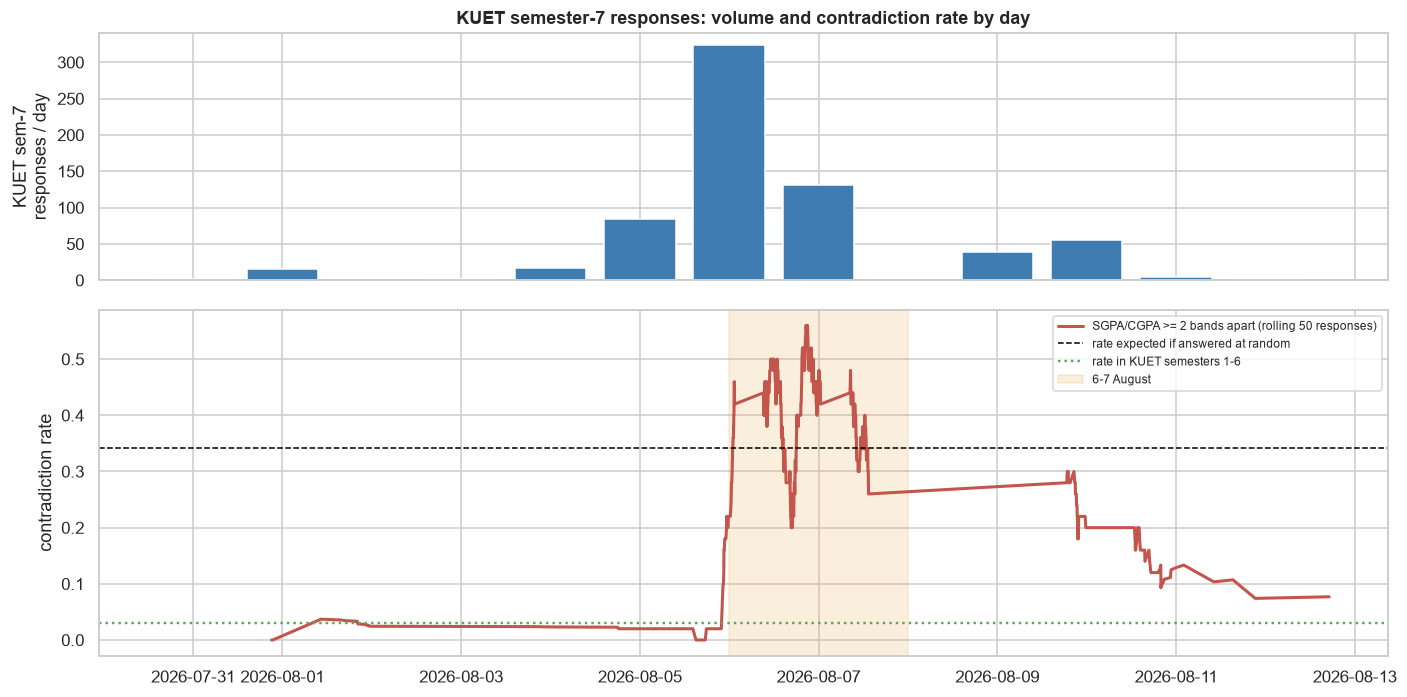

KUET sem 7, 31 Jul - 5 Aug     n= 120  far-gap 1.7%  SGPA-CGPA rho +0.77
KUET sem 7, 6-7 Aug (burst)    n= 455  far-gap 40.0%  SGPA-CGPA rho -0.04
KUET sem 7, 9 Aug onward       n= 100  far-gap 15.0%  SGPA-CGPA rho +0.34


In [7]:
k = df[df.source_form == "kuet"].sort_values("ts").reset_index(drop=True)
k7 = k[k.semester_raw == 7]
daily = k7.groupby("date").agg(responses=("far_gap", "size"), far_gap_rate=("far_gap", "mean"))
display(daily.round(3))

fig, axes = plt.subplots(2, 1, figsize=(13, 6.5), sharex=True, gridspec_kw={"height_ratios": [1, 1.4]})
axes[0].bar(pd.to_datetime(daily.index), daily.responses, color=PALETTE[0], width=.8)
axes[0].set_ylabel("KUET sem-7\nresponses / day")
axes[0].set_title("KUET semester-7 responses: volume and contradiction rate by day", fontweight="bold")
roll = k7.set_index("ts").far_gap.astype(float).rolling(50, min_periods=25, center=True).mean()
axes[1].plot(roll.index, roll.values, color=PALETTE[3], lw=2, label="SGPA/CGPA >= 2 bands apart (rolling 50 responses)")
axes[1].axhline(far_if_independent(k7), ls="--", c="black", lw=1, label="rate expected if answered at random")
axes[1].axhline(coh.loc["KUET sem 1-6", "observed far-gap rate"], ls=":", c=PALETTE[2], lw=1.6,
                label="rate in KUET semesters 1-6")
axes[1].axvspan(pd.Timestamp("2026-08-06"), pd.Timestamp("2026-08-08"), color=PALETTE[1], alpha=.18,
                label="6-7 August")
axes[1].set_ylabel("contradiction rate"); axes[1].legend(fontsize=8, loc="upper right")
plt.tight_layout()
save_fig("a04_contradiction_timeline")

df["burst"] = (df.source_form == "kuet") & (df.semester_raw == 7) & df.date.isin(["2026-08-06", "2026-08-07"])
pre = df[(df.source_form == "kuet") & (df.semester_raw == 7) & (df.ts < "2026-08-06")]
post = df[(df.source_form == "kuet") & (df.semester_raw == 7) & (df.ts >= "2026-08-08")]
for name, s in [("KUET sem 7, 31 Jul - 5 Aug", pre), ("KUET sem 7, 6-7 Aug (burst)", df[df.burst]),
                ("KUET sem 7, 9 Aug onward", post)]:
    print(f"{name:<30} n={len(s):>4}  far-gap {s.far_gap.mean():.1%}  SGPA-CGPA rho {s[['recent_sgpa_code','target_code']].corr('spearman').iloc[0,1]:+.2f}")

**The contradictions arrived in a burst.** KUET semester-7 students who answered from 31 July to
5 August are as consistent as every other cohort. On **6 and 7 August** the form received about
455 semester-7 responses in two days, and their SGPA and CGPA answers are close to unrelated. The
rate falls back afterwards.

We are careful about what this proves. It shows that one wave of responses behaves like random
filling on the GPA questions. It does not tell us *who* filled them or *why*.

### 4.3 Independent evidence that does not use the CGPA at all

Everything in §4.1–4.2 leans on the SGPA–CGPA relationship. If the burst rows are genuinely
careless, they should also look careless on answers that have **nothing to do with the target**.
We compute the standard careless-responding indicators from survey methodology:

| Indicator | What it catches |
|---|---|
| **Satisfaction contradiction** | "Very satisfied" with a last SGPA below 3.20, or "very dissatisfied" with 3.75+ — uses recent SGPA and result satisfaction, never the CGPA |
| **Mahalanobis distance** | an answer pattern unlike the rest of the sample across all 12 items |
| **Long-string** | the same option clicked many times in a row |
| **Intra-individual variability (IRV)** | very low = straight-lining |

,satisfaction_contradiction,admission_very_dissatisfied,mahalanobis,irv,longstring
wave,,,,,
everyone else,0.059,0.110,3.092,1.191,2.475
KUET sem 7: other days,0.045,0.286,3.066,1.177,2.550
KUET sem 7: 6-7 Aug burst,0.218,0.620,3.818,1.324,2.290


,indicator,burst,rest,test,p
0,satisfaction_contradiction,0.2176,0.0541,chi-square,0.0000
1,admission_very_dissatisfied,0.6198,0.1700,chi-square,0.0000
2,mahalanobis,3.8179,3.0833,Mann-Whitney U,0.0000
3,irv,1.3242,1.1860,Mann-Whitney U,0.0000
4,longstring,2.2901,2.5008,Mann-Whitney U,0.0001


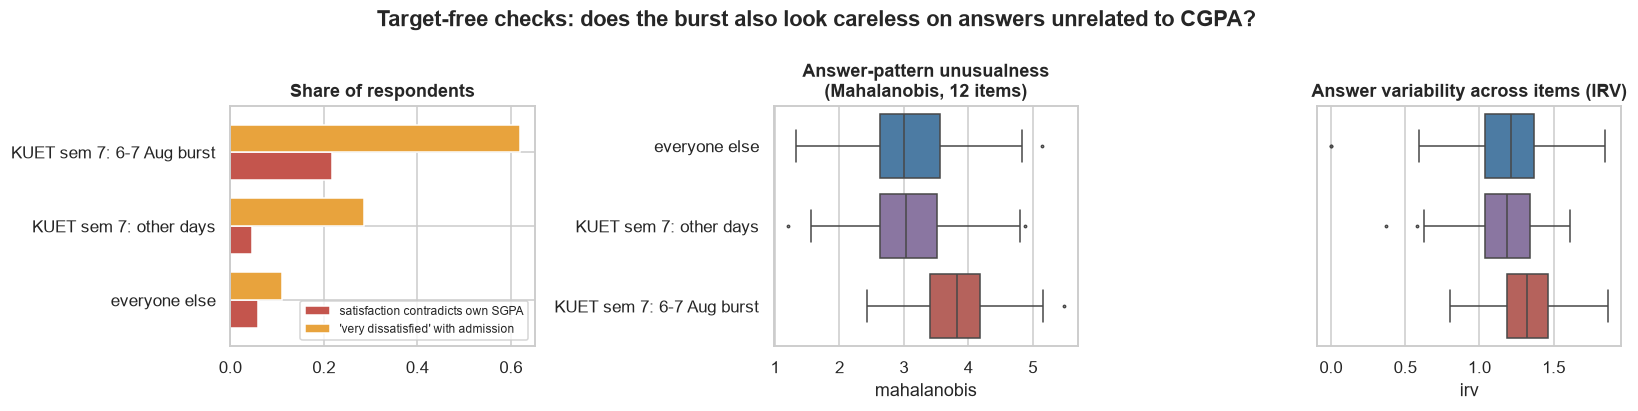

In [8]:
X = df[[i + "_code" for i in ITEMS]].to_numpy(float)
dev = X - X.mean(0)
df["mahalanobis"] = np.sqrt(np.einsum("ij,jk,ik->i", dev, np.linalg.pinv(np.cov(X, rowvar=False)), dev))
df["irv"] = X.std(axis=1)
def longstring(row):
    best = cur = 1
    for a, b in zip(row[:-1], row[1:]):
        cur = cur + 1 if a == b else 1
        best = max(best, cur)
    return best
df["longstring"] = [longstring(r) for r in X]
df["satisfaction_contradiction"] = (((df.result_satisfaction_code == 4) & (df.recent_sgpa_code == 0)) |
                                    ((df.result_satisfaction_code == 0) & (df.recent_sgpa_code == 3)))
df["admission_very_dissatisfied"] = df.admission_satisfaction_code == 0

ind = ["satisfaction_contradiction", "admission_very_dissatisfied", "mahalanobis", "irv", "longstring"]
df["wave"] = np.select([df.burst,
                        (df.source_form == "kuet") & (df.semester_raw == 7)],
                       ["KUET sem 7: 6-7 Aug burst", "KUET sem 7: other days"], default="everyone else")
waves = ["everyone else", "KUET sem 7: other days", "KUET sem 7: 6-7 Aug burst"]
display(df.groupby("wave")[ind].mean().reindex(waves).round(3))

tests = []
b, o = df[df.burst], df[~df.burst]
for col in ["satisfaction_contradiction", "admission_very_dissatisfied"]:
    tab = pd.crosstab(df.burst, df[col])
    tests.append({"indicator": col, "burst": b[col].mean(), "rest": o[col].mean(),
                  "test": "chi-square", "p": stats.chi2_contingency(tab)[1]})
for col in ["mahalanobis", "irv", "longstring"]:
    tests.append({"indicator": col, "burst": b[col].mean(), "rest": o[col].mean(),
                  "test": "Mann-Whitney U", "p": stats.mannwhitneyu(b[col], o[col]).pvalue})
tests = pd.DataFrame(tests)
display(tests.round(4))

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
share = df.groupby("wave")[["satisfaction_contradiction", "admission_very_dissatisfied"]].mean().reindex(waves)
share.plot(kind="barh", ax=axes[0], color=[PALETTE[3], PALETTE[1]], width=.75)
axes[0].set_title("Share of respondents"); axes[0].set_xlabel(""); axes[0].set_ylabel("")
axes[0].legend(["satisfaction contradicts own SGPA", "'very dissatisfied' with admission"], fontsize=8)
for ax, col, title in [(axes[1], "mahalanobis", "Answer-pattern unusualness\n(Mahalanobis, 12 items)"),
                       (axes[2], "irv", "Answer variability across items (IRV)")]:
    sns.boxplot(data=df, y="wave", x=col, order=waves, ax=ax, palette=[PALETTE[0], PALETTE[4], PALETTE[3]],
                fliersize=1.5)
    ax.set_title(title); ax.set_ylabel(""); ax.set_yticklabels([] if ax is not axes[1] else ax.get_yticklabels())
plt.suptitle("Target-free checks: does the burst also look careless on answers unrelated to CGPA?", fontweight="bold")
plt.tight_layout()
save_fig("a05_careless_indicators")

**Convergent evidence.** The wave rows contradict their own SGPA on the satisfaction question four
times as often (21.8% vs 5.4% elsewhere), and their answer patterns across the 12 items are more
unusual (higher Mahalanobis distance). These checks never touch the CGPA, so they cannot be an
artefact of the SGPA-CGPA test.

The straight-lining indicators point the *other* way, and that is informative too: wave
respondents have **higher** answer variability and **shorter** runs of identical clicks than
everyone else. They did not press the same button down the page — they clicked varied answers that
do not fit together. That is the signature of fast, careless filling, not of a bot or of someone who
agrees with everything.

The spike of "very dissatisfied with admission" on the KUET form, flagged in notebook `02` (§6.5),
also concentrates in the wave (62% vs 17% elsewhere) — which explains that earlier artefact.

### 4.4 "Too many prodigies at KUET?"

The team's hunch was that KUET has an implausible number of top-band students. We test it
directly by comparing CGPA-C3 share across the waves.

In [9]:
prod = df.groupby("wave").agg(n=("target_code", "size"),
                              CGPA_C3=("target_code", lambda s: (s == 3).mean()),
                              SGPA_C3=("recent_sgpa_code", lambda s: (s == 3).mean()),
                              SGPA_C3_but_CGPA_C0=("gap", lambda s: np.nan)).reindex(waves)
for w in waves:
    s = df[df.wave == w]
    prod.loc[w, "SGPA_C3_but_CGPA_C0"] = ((s.recent_sgpa_code == 3) & (s.target_code == 0)).mean()
    prod.loc[w, "SGPA_C0_but_CGPA_C3"] = ((s.recent_sgpa_code == 0) & (s.target_code == 3)).mean()
display(prod.round(3))
print("KUET overall CGPA C3 share:", f"{(df[df.source_form=='kuet'].target_code==3).mean():.1%}")

,n,CGPA_C3,SGPA_C3,SGPA_C3_but_CGPA_C0,SGPA_C0_but_CGPA_C3
wave,,,,,
everyone else,427,0.258,0.283,0.021,0.026
KUET sem 7: other days,220,0.136,0.191,0.005,0.005
KUET sem 7: 6-7 Aug burst,455,0.233,0.273,0.070,0.064


KUET overall CGPA C3 share: 21.8%


**Partly right, for a slightly different reason.** The share of C3 students at KUET is not
wildly out of line on its own. What *is* implausible is the number of "inconsistent prodigies" —
students reporting a top-band SGPA with a bottom-band CGPA, or the reverse — and those are
concentrated in the burst. The anomaly is not too many top students; it is too many answers that
cannot all be true at once.

## 5. Check 5 — is the low accuracy everywhere, or in one place?

The teacher asked for KUET only and 4th semester only. We run those, and — because §4 pointed at
a specific wave of responses — we also split KUET semester 7 by *when* students answered.

**Protocol.** 5-fold stratified CV, repeated with seeds 1–5, confusion matrices summed across the
five repetitions. Small subsets (the 4th-semester group has 67–75 students) give noisy single
runs; repeating and pooling is the honest way to report them. Each subset gets its own ZeroR,
because "good accuracy" only means something against that subset's own majority class.

In [10]:
WORK = W.ARFF_DIR / "_work"                       # auxiliary ARFFs (subsets, permutations, resamples)
WORK.mkdir(exist_ok=True)
(WORK / ".gitignore").write_text("*\n")

def pooled(results, label):
    """Sum the confusion matrices of repeated WEKA runs into one result; keep the run-to-run spread."""
    cm = sum(r.cm for r in results)
    out = W.WekaResult(label, cm, "", results[0].command, dict(results[0].extra))
    out.extra["acc_std"] = float(np.std([r.accuracy for r in results]))
    out.extra["repeats"] = len(results)
    return out

def tag(s):
    return "".join(ch for ch in s if ch.isalnum())

SUBSETS = {
    "All students":            np.ones(len(df), bool),
    "Multi-uni only":          (df.source_form == "multi_uni").values,
    "KUET only":               (df.source_form == "kuet").values,
    "KUET sem 1-6":            ((df.source_form == "kuet") & (df.semester_raw != 7)).values,
    "KUET sem 4":              ((df.source_form == "kuet") & (df.semester_raw == 4)).values,
    "All sem 4":               (df.semester_raw == 4).values,
    "KUET sem 7":              ((df.source_form == "kuet") & (df.semester_raw == 7)).values,
    "KUET sem 7 before 6 Aug": ((df.source_form == "kuet") & (df.semester_raw == 7) & (df.ts < "2026-08-06")).values,
    "KUET sem 7, 6-7 Aug":     df.burst.values,
    "KUET sem 7 after 7 Aug":  ((df.source_form == "kuet") & (df.semester_raw == 7) & (df.ts >= "2026-08-08")).values,
}
SUB_MODELS = {"ZeroR": W.ZEROR, "J48": W.J48, "RandomForest": W.RF, "SMO": W.SMO, "Logistic": W.LOGISTIC}

jobs, sizes = [], []
for sname, mask in SUBSETS.items():
    sub = df[mask].reset_index(drop=True)
    counts = sub.target_code.value_counts().reindex(range(4), fill_value=0).tolist()
    sizes.append({"subset": sname, "n": len(sub), "C0/C1/C2/C3": counts,
                  "own SGPA-CGPA far gap": sub.far_gap.mean()})
    for dname, kw in [("main", {}), ("quest", {"with_sgpa": False})]:
        path = make_arff(sub, f"_work/sub_{tag(sname)}_{dname}", **kw)
        for mname, scheme in SUB_MODELS.items():
            for s in range(1, 6):
                jobs.append(dict(name=f"bulk/B_{tag(sname)}_{dname}_{mname}_cv5_s{s}", scheme=scheme,
                                 train=path, folds=5, seed=s, subset=sname, data=dname, model=mname))
groups = {}
for r in W.run_many(jobs):
    groups.setdefault((r.extra["subset"], r.extra["data"], r.extra["model"]), []).append(r)
subset_res = {k: pooled(v, "|".join(k)) for k, v in groups.items()}
sub_tbl = pd.DataFrame([{**r.row(), "subset": k[0], "data": k[1], "model": k[2]} for k, r in subset_res.items()])

display(pd.DataFrame(sizes).set_index("subset").round(3))
acc = sub_tbl[sub_tbl.data == "main"].pivot_table(index="subset", columns="model", values="accuracy").reindex(SUBSETS)
display((acc * 100).round(1).rename(columns=lambda c: c + " %"))

,n,C0/C1/C2/C3,own SGPA-CGPA far gap
subset,,,
All students,1102,"[236, 320, 300, 246]",0.220
Multi-uni only,230,"[52, 61, 61, 56]",0.161
KUET only,872,"[184, 259, 239, 190]",0.235
KUET sem 1-6,197,"[37, 54, 52, 54]",0.030
KUET sem 4,67,"[17, 11, 20, 19]",0.045
All sem 4,75,"[20, 12, 20, 23]",0.080
KUET sem 7,675,"[147, 205, 187, 136]",0.295
KUET sem 7 before 6 Aug,120,"[15, 48, 35, 22]",0.017
"KUET sem 7, 6-7 Aug",455,"[111, 117, 121, 106]",0.400


model,J48 %,Logistic %,RandomForest %,SMO %,ZeroR %
subset,,,,,
All students,43.7,45.6,45.2,46.1,29.0
Multi-uni only,51.7,46.6,50.2,48.8,26.1
KUET only,42.8,43.6,43.6,44.6,29.7
KUET sem 1-6,78.1,73.9,80.7,81.5,26.9
KUET sem 4,29.9,58.5,79.1,80.3,29.9
All sem 4,30.7,56.0,74.1,76.5,30.7
KUET sem 7,31.0,31.7,31.7,31.7,30.4
KUET sem 7 before 6 Aug,36.7,51.2,59.5,62.5,40.0
"KUET sem 7, 6-7 Aug",25.7,24.4,25.4,25.8,26.6


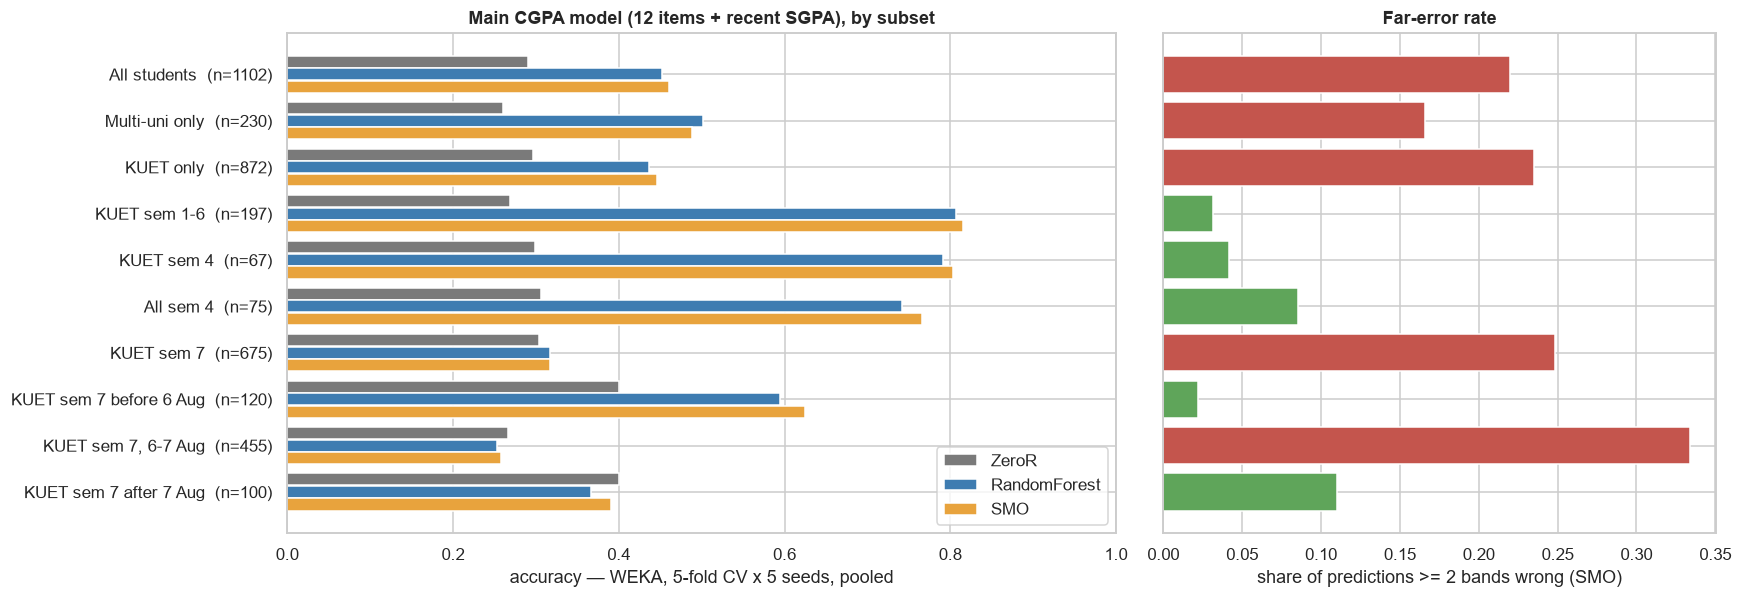

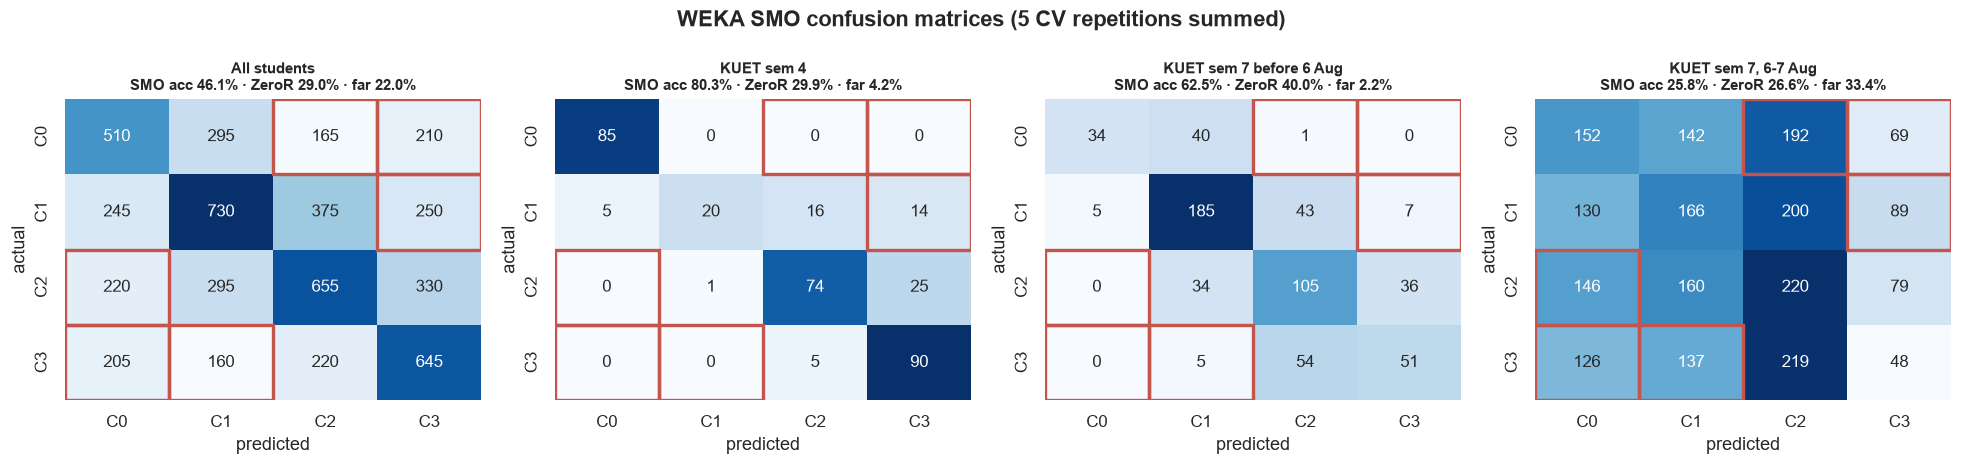

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.6), gridspec_kw={"width_ratios": [1.5, 1]})
names = list(SUBSETS)
y = np.arange(len(names))
for off, m, col in [(-.27, "ZeroR", PALETTE[5]), (0, "RandomForest", PALETTE[0]), (.27, "SMO", PALETTE[1])]:
    vals = [subset_res[(n, "main", m)].accuracy for n in names]
    axes[0].barh(y + off, vals, height=.26, color=col, label=m)
axes[0].set_yticks(y); axes[0].set_yticklabels([f"{n}  (n={int(SUBSETS[n].sum())})" for n in names])
axes[0].invert_yaxis(); axes[0].set_xlim(0, 1)
axes[0].set_xlabel("accuracy — WEKA, 5-fold CV x 5 seeds, pooled"); axes[0].legend(loc="lower right")
axes[0].set_title("Main CGPA model (12 items + recent SGPA), by subset")
far = [subset_res[(n, "main", "SMO")].far_rate for n in names]
axes[1].barh(y, far, color=[PALETTE[3] if v > .15 else PALETTE[2] for v in far])
axes[1].set_yticks(y); axes[1].set_yticklabels([]); axes[1].invert_yaxis()
axes[1].set_xlabel("share of predictions >= 2 bands wrong (SMO)")
axes[1].set_title("Far-error rate")
plt.tight_layout()
save_fig("a06_subsets_accuracy")

fig, axes = plt.subplots(1, 4, figsize=(18, 4.3))
for ax, n in zip(axes, ["All students", "KUET sem 4", "KUET sem 7 before 6 Aug", "KUET sem 7, 6-7 Aug"]):
    r = subset_res[(n, "main", "SMO")]
    cm_plot(ax, r.cm, f"{n}\nSMO acc {r.accuracy:.1%} · ZeroR {subset_res[(n, 'main', 'ZeroR')].accuracy:.1%} · far {r.far_rate:.1%}")
plt.suptitle("WEKA SMO confusion matrices (5 CV repetitions summed)", fontweight="bold")
plt.tight_layout()
save_fig("a07_subset_confusion_matrices")

**The low accuracy is not a property of the whole dataset. It is concentrated.**

| Subset | What WEKA shows (SMO, 5-fold CV x 5 seeds) |
|---|---|
| **KUET semesters 1-6** | 81.5% against a 26.9% floor; far errors 3.1%. |
| **KUET 4th semester** (the teacher's check) | 80.3% against a 29.9% floor (4th semester, all universities: 76.5%). |
| **KUET semester 7, before 6 August** | 62.5% against a 40.0% floor — healthy. |
| **KUET semester 7, 6-7 August** | **25.8% against its own 26.6% ZeroR.** Nothing is learnable in these 455 rows. |
| **KUET semester 7, after 7 August** | 39.0% against 40.0% — only 100 rows, still partly contaminated (15% far gaps). |
| **Whole dataset** | 46.1%: a weighted average of learnable data and a large block of unlearnable data. |

Three footnotes a viva panel will ask about:

- **Do not read ~80% as "the model is excellent".** In early semesters the CGPA averages only a
  few semesters, and on the KUET form one of them *is* the recent SGPA the model is given — every
  KUET semester-2 student reports the same band for both. There the target nearly equals an input
  by construction. The comparison that isolates data quality is *inside one cohort*: KUET semester
  7 before 6 August (62.5%) and the 6-7 August wave (25.8%) have the same overlap structure, so the
  37-point gap is the wave, not the arithmetic.
- **J48 scores exactly ZeroR on the 4th-semester subsets.** That is a setting, not a finding:
  `-M 40` needs at least 40 students per leaf, and with 67 students no split can leave 40 on both
  sides, so the tree is a single leaf. §8.2 discusses leaf size.
- The 4th-semester result rests on 67-75 students; the run-to-run spread is in the table below.

In [12]:
for d, label in [("main", "12 items + recent SGPA"), ("quest", "12 items only (behaviour)")]:
    t = sub_tbl[(sub_tbl.data == d) & (sub_tbl.model.isin(["ZeroR", "RandomForest", "SMO"]))]
    t = t.pivot_table(index="subset", columns="model", values=["accuracy", "acc_std", "qwk", "far_rate"]).reindex(SUBSETS)
    print(f"\n{label}")
    display(t.round(3))


12 items + recent SGPA


acc_std                  accuracy                \
model                   RandomForest    SMO ZeroR RandomForest    SMO  ZeroR   
subset                                                                         
All students                   0.005  0.000   0.0        0.452  0.461  0.290   
Multi-uni only                 0.008  0.020   0.0        0.502  0.488  0.261   
KUET only                      0.006  0.000   0.0        0.436  0.446  0.297   
KUET sem 1-6                   0.011  0.002   0.0        0.807  0.815  0.269   
KUET sem 4                     0.019  0.006   0.0        0.791  0.803  0.299   
All sem 4                      0.011  0.011   0.0        0.741  0.765  0.307   
KUET sem 7                     0.010  0.006   0.0        0.317  0.317  0.304   
KUET sem 7 before 6 Aug        0.014  0.009   0.0        0.595  0.625  0.400   
KUET sem 7, 6-7 Aug            0.014  0.009   0.0        0.254  0.258  0.266   
KUET sem 7 after 7 Aug         0.042  0.035   0.0        0.366  0.390  0.400   

                            far_rate                        qwk                
model                   RandomForest    SMO  ZeroR RandomForest    SMO  ZeroR  
subset                                                                         
All students                   0.212  0.220  0.223        0.304  0.322  0.000  
Multi-uni only                 0.180  0.166  0.239        0.365  0.405 -0.001  
KUET only                      0.216  0.235  0.218        0.292  0.293  0.000  
KUET sem 1-6                   0.026  0.031  0.319        0.885  0.883 -0.019  
KUET sem 4                     0.039  0.042  0.254        0.881  0.886  0.000  
All sem 4                      0.075  0.085  0.427        0.751  0.763  0.000  
KUET sem 7                     0.279  0.249  0.201        0.052  0.069  0.000  
KUET sem 7 before 6 Aug        0.040  0.022  0.183        0.656  0.717  0.000  
KUET sem 7, 6-7 Aug            0.366  0.334  0.244       -0.029  0.008  0.000  
KUET sem 7 after 7 Aug         0.126  0.110  0.080        0.145  0.158  0.000


12 items only (behaviour)


acc_std                  accuracy                \
model                   RandomForest    SMO ZeroR RandomForest    SMO  ZeroR   
subset                                                                         
All students                   0.006  0.008   0.0        0.310  0.281  0.290   
Multi-uni only                 0.022  0.021   0.0        0.357  0.302  0.261   
KUET only                      0.005  0.010   0.0        0.314  0.276  0.297   
KUET sem 1-6                   0.010  0.013   0.0        0.384  0.351  0.269   
KUET sem 4                     0.049  0.047   0.0        0.322  0.287  0.299   
All sem 4                      0.039  0.034   0.0        0.328  0.325  0.307   
KUET sem 7                     0.013  0.014   0.0        0.284  0.282  0.304   
KUET sem 7 before 6 Aug        0.018  0.030   0.0        0.390  0.393  0.400   
KUET sem 7, 6-7 Aug            0.022  0.009   0.0        0.246  0.265  0.266   
KUET sem 7 after 7 Aug         0.039  0.016   0.0        0.342  0.338  0.400   

                            far_rate                        qwk                
model                   RandomForest    SMO  ZeroR RandomForest    SMO  ZeroR  
subset                                                                         
All students                   0.297  0.219  0.223        0.058  0.055  0.000  
Multi-uni only                 0.327  0.338  0.239        0.040  0.015 -0.001  
KUET only                      0.284  0.220  0.218        0.057  0.055  0.000  
KUET sem 1-6                   0.220  0.262  0.319        0.317  0.269 -0.019  
KUET sem 4                     0.284  0.319  0.254        0.173  0.118  0.000  
All sem 4                      0.309  0.323  0.427        0.203  0.131  0.000  
KUET sem 7                     0.288  0.216  0.201       -0.001  0.019  0.000  
KUET sem 7 before 6 Aug        0.152  0.153  0.183        0.247  0.153  0.000  
KUET sem 7, 6-7 Aug            0.389  0.335  0.244       -0.066  0.001  0.000  
KUET sem 7 after 7 Aug         0.172  0.122  0.080       -0.009 -0.038  0.000

The behaviour-only rows (second table) stay near their floors everywhere except KUET semesters
1–6, where Random Forest gains roughly ten points. Habits alone are a weak signal even in clean
data — that part of notebook `02`'s conclusion stands.

## 6. Check 2 — does 5-fold CV or a train/test split change the picture?

**Short answer: no, and it should not.** The evaluation scheme changes how accurately we
*measure* a model; it does not change what the model can learn. We verify that, and we show why a
single train/test split misled the deck.

In [13]:
EVALS = {"10-fold CV": dict(folds=10), "5-fold CV": dict(folds=5),
         "80/20 split": dict(split=80), "70/30 split": dict(split=70)}
jobs = []
for dname, path in [("main", MAIN), ("quest", QUEST)]:
    for mname, scheme in W.STANDARD_MODELS.items():
        for ename, kw in EVALS.items():
            jobs.append(dict(name=f"C_{dname}_{mname}_{tag(ename)}", scheme=scheme, train=path, seed=1,
                             data=dname, model=mname, evaluation=ename, **kw))
eval_tbl = pd.DataFrame([r.row() for r in W.run_many(jobs)])
display((eval_tbl.pivot_table(index=["data", "model"], columns="evaluation", values="accuracy")
         [list(EVALS)] * 100).round(1))

evaluation          10-fold CV  5-fold CV  80/20 split  70/30 split
data  model                                                        
main  J48                 43.3       43.6         38.6         42.9
      Logistic            45.7       46.4         44.5         48.6
      NaiveBayes          44.3       44.8         45.9         47.7
      RandomForest        45.0       45.0         50.5         47.7
      SMO                 46.1       46.1         44.5         48.0
      ZeroR               29.0       29.0         25.9         27.2
quest J48                 26.5       28.0         34.1         30.2
      Logistic            29.6       28.8         31.4         27.2
      NaiveBayes          30.0       29.8         30.5         31.7
      RandomForest        32.9       31.0         29.1         32.3
      SMO                 28.3       28.3         26.8         26.6
      ZeroR               29.0       29.0         25.9         27.2

mean  std   min   max  count
model        evaluation                                          
J48          10-fold CV (10 seeds)   43.4  0.8  42.2  44.9     10
             5-fold CV (10 seeds)    43.5  1.2  41.7  45.6     10
             80/20 split (30 seeds)  43.3  2.9  37.3  48.6     30
RandomForest 10-fold CV (10 seeds)   45.6  0.9  44.0  47.2     10
             5-fold CV (10 seeds)    45.4  0.6  44.4  46.4     10
             80/20 split (30 seeds)  44.5  3.2  36.8  50.5     30
SMO          10-fold CV (10 seeds)   46.1  0.0  46.1  46.1     10
             5-fold CV (10 seeds)    46.1  0.0  46.1  46.1     10
             80/20 split (30 seeds)  45.6  3.4  37.3  50.9     30

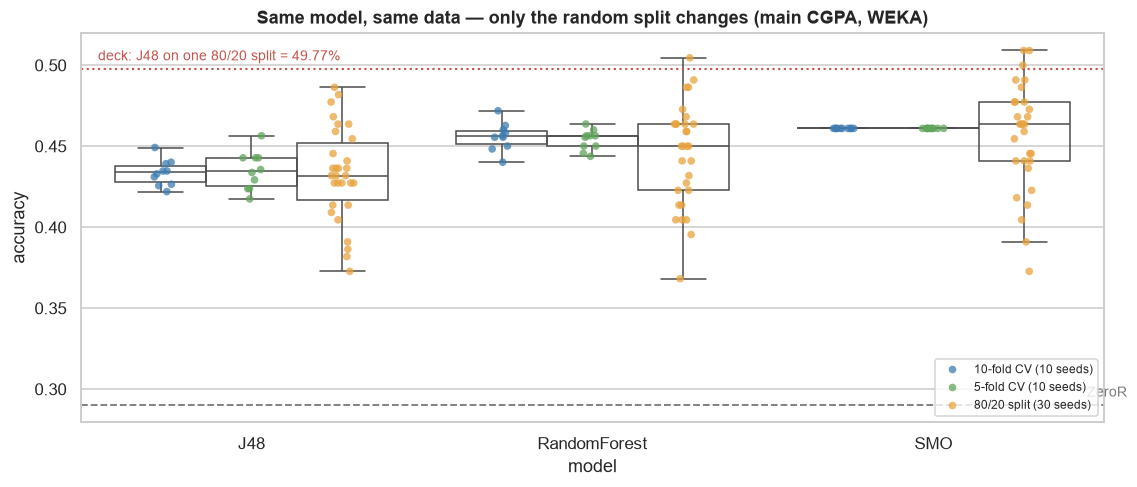

In [14]:
jobs = []
for mname in ["J48", "RandomForest", "SMO"]:
    for s in range(1, 31):
        jobs.append(dict(name=f"bulk/C_var_{mname}_split80_s{s}", scheme=W.STANDARD_MODELS[mname], train=MAIN,
                         split=80, seed=s, model=mname, evaluation="80/20 split (30 seeds)"))
    for s in range(1, 11):
        for k in (10, 5):
            jobs.append(dict(name=f"bulk/C_var_{mname}_cv{k}_s{s}", scheme=W.STANDARD_MODELS[mname], train=MAIN,
                             folds=k, seed=s, model=mname, evaluation=f"{k}-fold CV (10 seeds)"))
var_tbl = pd.DataFrame([r.row() for r in W.run_many(jobs)])
spread = var_tbl.groupby(["model", "evaluation"]).accuracy.agg(["count", "mean", "std", "min", "max"])
display((spread[["mean", "std", "min", "max"]] * 100).round(1).join(spread["count"]))

fig, ax = plt.subplots(figsize=(12, 4.6))
order = ["10-fold CV (10 seeds)", "5-fold CV (10 seeds)", "80/20 split (30 seeds)"]
sns.stripplot(data=var_tbl, x="model", y="accuracy", hue="evaluation", hue_order=order, dodge=True,
              palette=[PALETTE[0], PALETTE[2], PALETTE[1]], size=5, alpha=.75, ax=ax)
sns.boxplot(data=var_tbl, x="model", y="accuracy", hue="evaluation", hue_order=order, dodge=True,
            showfliers=False, boxprops={"facecolor": "none"}, ax=ax, legend=False)
ax.axhline(base_zr.accuracy, ls="--", c=PALETTE[5], lw=1.2)
ax.text(2.45, base_zr.accuracy + .005, "ZeroR", color=PALETTE[5], fontsize=9)
ax.axhline(.4977, ls=":", c=PALETTE[3], lw=1.4)
ax.text(-.45, .503, "deck: J48 on one 80/20 split = 49.77%", color=PALETTE[3], fontsize=9)
ax.set_title("Same model, same data — only the random split changes (main CGPA, WEKA)")
ax.legend(title="", fontsize=8, loc="lower right")
save_fig("a08_evaluation_scheme_spread")

**What this shows.**

1. **10-fold and 5-fold CV agree to within about a point** for every model (SMO: 46.1% both).
   Switching to 5-fold changes nothing, because nothing about the *data* changed.
2. **A single 80/20 split is a lottery.** The same WEKA model, re-run on 30 random splits, ranges
   over 11-14 accuracy points (Random Forest 36.8%-50.5%, SMO 37.3%-50.9%). Cross-validation uses
   every student as a test case, so its spread across seeds stays under 1.2 points.
3. **This explains a number in the deck.** "J48 main CGPA: 49.77% on the test set" is higher than
   all 30 of our random J48 splits (maximum 48.6%) for a model whose cross-validated accuracy is
   43.3%. It is a real WEKA output — a lucky draw, not a representative one.

**Recommendation:** report 10-fold CV as the result. If a train/test split is shown for teaching,
say it is one draw and show the spread beside it.

## 7. Check 3 — what happens when features get different weights?

"Weighting a feature" means making the model pay more attention to it. Whether that changes
anything depends entirely on **how the model uses distances or magnitudes**, so we test the
model families separately:

| Family | WEKA scheme | Should scaling a feature matter? |
|---|---|---|
| Decision trees | J48, RandomForest | **No** — a tree asks "is SGPA ≤ 1?"; multiplying SGPA by 4 just moves the threshold to 4 |
| Probabilistic / linear with negligible penalty | Logistic (ridge 1.0) | **Barely** — a coefficient simply rescales to compensate |
| Distance-based | IBk (k-NN) with normalisation turned **off** | **Yes** — a bigger feature dominates the distance |
| Margin-based | SMO with normalisation turned **off** (`-N 2`) | **Yes** — the margin is measured in feature units |

We weight recent SGPA by `w` (0 = ignore it, 8 = let it dominate) and keep the 12 behaviour items
at weight 1. WEKA normally normalises attributes for IBk and SMO, which would silently undo any
weighting — so we disable it for this experiment only.

model,IBk k=25 (no normalisation),J48,Logistic (ridge 1),RandomForest,SMO (no normalisation)
weight,,,,,
0.00,30.1,26.5,29.4,29.9,26.1
0.25,31.9,43.3,36.8,44.0,29.5
0.50,32.8,43.3,36.8,43.6,32.3
1.00,36.8,43.3,36.8,45.3,33.5
2.00,41.6,43.3,36.8,44.0,33.6
4.00,46.5,43.3,36.8,43.0,31.8
8.00,46.5,43.3,36.8,45.4,31.9


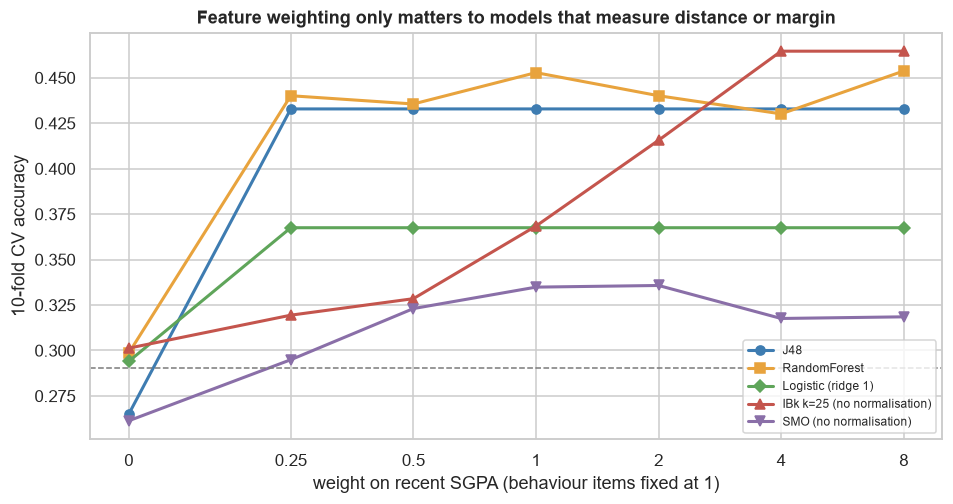

In [15]:
IBK_RAW = ["weka.classifiers.lazy.IBk", "-K", "25", "-W", "0", "-A",
           'weka.core.neighboursearch.LinearNNSearch -A "weka.core.EuclideanDistance -D -R first-last"']
SMO_RAW = ["weka.classifiers.functions.SMO", "-N", "2"]
LOG_RIDGE = ["weka.classifiers.functions.Logistic", "-R", "1.0", "-M", "-1"]
WEIGHT_MODELS = {"J48": W.J48, "RandomForest": W.RF, "Logistic (ridge 1)": LOG_RIDGE,
                 "IBk k=25 (no normalisation)": IBK_RAW, "SMO (no normalisation)": SMO_RAW}
WEIGHTS = [0, 0.25, 0.5, 1, 2, 4, 8]

jobs = []
for w in WEIGHTS:
    table, nominal, cls = weka_frame(df, sgpa_numeric=True)
    table["recent_sgpa"] = table["recent_sgpa"] * w
    path = W.write_arff(table, WORK / f"weight_sgpa_{tag(str(w))}.arff", f"weight_sgpa_{w}", nominal)
    for mname, scheme in WEIGHT_MODELS.items():
        jobs.append(dict(name=f"D_weight_sgpa{tag(str(w))}_{tag(mname)}", scheme=scheme, train=path,
                         weight=w, model=mname))
weight_tbl = pd.DataFrame([r.row() for r in W.run_many(jobs)])
display((weight_tbl.pivot_table(index="weight", columns="model", values="accuracy") * 100).round(1))

fig, ax = plt.subplots(figsize=(10, 4.8))
for (mname, col, mk) in zip(WEIGHT_MODELS, PALETTE, "osD^v"):
    d = weight_tbl[weight_tbl.model == mname].sort_values("weight")
    ax.plot(d.weight.replace(0, 0.1), d.accuracy, marker=mk, color=col, lw=2, label=mname)
ax.set_xscale("log"); ax.set_xticks([0.1, 0.25, 0.5, 1, 2, 4, 8])
ax.set_xticklabels(["0", "0.25", "0.5", "1", "2", "4", "8"])
ax.axhline(base_zr.accuracy, ls="--", c=PALETTE[5], lw=1)
ax.set_xlabel("weight on recent SGPA (behaviour items fixed at 1)"); ax.set_ylabel("10-fold CV accuracy")
ax.set_title("Feature weighting only matters to models that measure distance or margin")
ax.legend(fontsize=8)
save_fig("a09_feature_weight_curves")

**Exactly what the theory predicts, measured in WEKA.**

- **J48 does not move at all** once SGPA has any non-zero weight (43.3% at every weight) — the tree
  finds the same split at a rescaled threshold. Random Forest wobbles between 43.0% and 45.4% with
  no trend; that is its internal randomness. Logistic regression is flat.
- **IBk climbs from 30.1% to 46.5%** as SGPA's weight rises. With equal weights, twelve noisy
  behaviour items drown the one informative feature in the distance; weighting SGPA up makes a
  student's neighbours the students with a similar SGPA.
- **SMO without normalisation** rises then falls (26.1% -> 33.6% -> 31.9%) and never reaches normal
  SMO (46.1%): raw-scale weights distort the margin, and WEKA's default normalisation is doing
  useful work.
- **At weight 0 every model collapses to the behaviour-only level** (26-30%) — the plainest
  demonstration that recent SGPA carries the prediction.

So assigning weights *can* change results, but only for distance/margin models, and only by
compensating for noisy features. It adds no information the data did not already have.

### 7.1 Weights of zero — letting WEKA choose the features

The most extreme weighting is 0 or 1: keep a feature or drop it. WEKA's
`AttributeSelectedClassifier` ranks features by information gain **inside each CV fold** (so the
held-out students never influence the choice) and keeps the top *k*.

We also check one encoding question that turned out to explain another inconsistency in the deck:
should recent SGPA be a **nominal** attribute (four separate values) or a **numeric** code (0–3)?

In [16]:
jobs = []
for k in [1, 2, 4, 8, 13]:
    for mname, scheme in [("J48", W.J48), ("RandomForest", W.RF), ("Logistic", W.LOGISTIC), ("SMO", W.SMO)]:
        jobs.append(dict(name=f"D_topk{k}_{mname}",
                         scheme=["weka.classifiers.meta.AttributeSelectedClassifier",
                                 "-E", "weka.attributeSelection.InfoGainAttributeEval",
                                 "-S", f"weka.attributeSelection.Ranker -T -1.7976931348623157E308 -N {k}",
                                 "-W", scheme[0]],
                         train=MAIN, base=scheme[1:] or None, k=k, model=mname))
topk_tbl = pd.DataFrame([r.row() for r in W.run_many(jobs)])
display((topk_tbl.pivot_table(index="k", columns="model", values="accuracy") * 100).round(1))

MAIN_NUM = make_arff(df, "main_cgpa_1102_numeric_sgpa", sgpa_numeric=True)
jobs = []
for mname, scheme in W.STANDARD_MODELS.items():
    for enc, path in [("nominal", MAIN), ("numeric", MAIN_NUM)]:
        jobs.append(dict(name=f"D_encoding_{enc}_{mname}", scheme=scheme, train=path, encoding=enc, model=mname))
enc_tbl = pd.DataFrame([r.row() for r in W.run_many(jobs)])
enc_view = (enc_tbl.pivot_table(index="model", columns="encoding", values="accuracy") * 100).round(1)
deck36 = {"J48": 38.29, "RandomForest": 43.92, "SMO": 37.11, "Logistic": 36.84, "NaiveBayes": 38.11, "ZeroR": 29.04}
deck63 = {"J48": 39.8, "RandomForest": 46.3, "SMO": 46.5, "Logistic": 45.1, "NaiveBayes": 39.7, "ZeroR": 29.0}
enc_view["deck slide 36"] = pd.Series(deck36)
enc_view["deck slide 63"] = pd.Series(deck63)
display(enc_view)

model,J48,Logistic,RandomForest,SMO
k,,,,
1,46.1,46.1,46.1,46.1
2,46.1,46.1,44.1,46.1
4,45.0,46.1,36.8,46.1
8,46.2,46.1,41.7,46.1
13,43.3,45.7,45.0,46.1


encoding,nominal,numeric,deck slide 36,deck slide 63
model,,,,
J48,43.3,43.3,38.29,39.8
Logistic,45.7,36.8,36.84,45.1
NaiveBayes,44.3,38.1,38.11,39.7
RandomForest,45.0,45.3,43.92,46.3
SMO,46.1,37.1,37.11,46.5
ZeroR,29.0,29.0,29.04,29.0


**Two findings.**

1. **Top-1 is as good as all 13.** Information gain ranks recent SGPA first, and that single
   feature gives 46.1% with every model — equal to or better than the 13-feature versions. On the
   full data the twelve behaviour items add no predictive accuracy.
2. **Encoding explains the deck's two conflicting result tables.** With SGPA as a *numeric* code,
   WEKA gives SMO 37.1%, Logistic 36.8%, Naive Bayes 38.1% — the deck's slide 36 to within 0.05
   points. As a *nominal* attribute they give 46.1%, 45.7%, 44.3% — the range of the deck's slide
   63. Nominal gives each SGPA band its own weight ("SGPA = C1 -> vote C1"); one numeric slope per
   class cannot bend to fit the middle bands. Trees split either encoding the same way, so J48 and
   Random Forest barely move.

   Both deck tables put J48 at 38-40% while ours gives 43.3%. That gap is leaf size, not encoding:
   WEKA's default J48 (`-M 2`) gives 38.0% here — see §8.2.

**Recommendation:** encode recent SGPA as nominal, and quote one table.

## 8. Check 6 — do the three decision trees mean anything?

The deck shows three WEKA J48 trees: behaviour → recent SGPA, behaviour → CGPA, and behaviour +
recent SGPA → CGPA. A tree always *looks* meaningful — it prints confident IF–THEN rules even on
pure noise. So we put each one through two tests that noise cannot pass.

**Test 1 — label permutation.** Shuffle the class column, which destroys any real link between
answers and grades while keeping everything else identical, and let J48 learn from it. Repeat 99
times. If the real tree does not beat the shuffled trees, its accuracy is what a tree achieves
from noise. (With 99 shuffles the smallest possible p-value is 1/100 = 0.01.)

**Test 2 — stability.** The team's trees came from one 80% training sample. Draw 30 different
80% samples and let J48 build a tree on each. A real structure keeps the same top split; a
noise-fitted tree picks a different root almost every time.

In [17]:
TREES = {"T1: behaviour -> SGPA": dict(target="sgpa", with_sgpa=False),
         "T2: behaviour -> CGPA": dict(target="cgpa", with_sgpa=False),
         "T3: behaviour + SGPA -> CGPA": dict(target="cgpa", with_sgpa=True)}
N_PERM, N_SUB = 99, 30
rng = np.random.default_rng(2026)
jobs = []
for tname, kw in TREES.items():
    t = tname.split(":")[0]
    real = make_arff(df, f"_work/tree_{t}_real", **kw)
    jobs.append(dict(name=f"E_{t}_J48_cv10", scheme=W.J48, train=real, tree=tname, kind="real"))
    jobs.append(dict(name=f"E_{t}_ZeroR_cv10", scheme=W.ZEROR, train=real, tree=tname, kind="zeror"))
    jobs.append(dict(name=f"E_{t}_J48default_full", scheme=["weka.classifiers.trees.J48"], train=real,
                     keep_model=True, tree=tname, kind="default_M2"))
    jobs.append(dict(name=f"E_{t}_J48M40_full", scheme=W.J48, train=real, keep_model=True, tree=tname, kind="M40_full"))
    label_col = "recent_sgpa_code" if kw["target"] == "sgpa" else "target_code"
    for p in range(N_PERM):
        shuffled = df.copy()
        shuffled[label_col] = df[label_col].values[rng.permutation(len(df))]
        path = make_arff(shuffled, f"_work/tree_{t}_perm{p:02d}", **kw)
        jobs.append(dict(name=f"bulk/E_{t}_perm{p:02d}", scheme=W.J48, train=path, tree=tname, kind="perm"))
    for b in range(N_SUB):
        tr = df.sample(frac=.8, random_state=500 + b)
        te = df.drop(tr.index)
        ptr = make_arff(tr, f"_work/tree_{t}_sub{b:02d}_train", **kw)
        pte = make_arff(te, f"_work/tree_{t}_sub{b:02d}_test", **kw)
        jobs.append(dict(name=f"bulk/E_{t}_sub{b:02d}", scheme=W.J48, train=ptr, test=pte, keep_model=True,
                         tree=tname, kind="subsample"))
tree_runs = W.run_many(jobs)
tree_tbl = pd.DataFrame([r.row() for r in tree_runs])

summary = []
for tname in TREES:
    d = tree_tbl[tree_tbl.tree == tname]
    real = d[d.kind == "real"].accuracy.iloc[0]
    null = d[d.kind == "perm"].accuracy
    sub = d[d.kind == "subsample"]
    top_root = sub.root.value_counts()
    summary.append({
        "tree": tname,
        "J48 10-fold acc": real,
        "ZeroR": d[d.kind == "zeror"].accuracy.iloc[0],
        "shuffled-label mean": null.mean(),
        "shuffled 95th pct": null.quantile(.95),
        "permutation p": (1 + (null >= real).sum()) / (1 + len(null)),
        "most common root": f"{top_root.index[0]} ({top_root.iloc[0]}/{N_SUB})",
        "distinct roots": top_root.size,
        "resample test acc (mean ± sd)": f"{sub.accuracy.mean():.3f} ± {sub.accuracy.std():.3f}",
        "leaves, -M 40": int(d[d.kind == "M40_full"].leaves.iloc[0]),
        "leaves, default -M 2": int(d[d.kind == "default_M2"].leaves.iloc[0]),
    })
tree_summary = pd.DataFrame(summary).set_index("tree")
display(tree_summary.round(3))

,J48 10-fold acc,ZeroR,shuffled-label mean,shuffled 95th pct,permutation p,most common root,distinct roots,resample test acc (mean ± sd),"leaves, -M 40","leaves, default -M 2"
tree,,,,,,,,,,
T1: behaviour -> SGPA,0.280,0.269,0.253,0.277,0.05,topic_clarity (13/30),7,0.270 ± 0.028,15,272
T2: behaviour -> CGPA,0.265,0.290,0.265,0.290,0.52,desired_department_match (19/30),6,0.278 ± 0.029,13,265
T3: behaviour + SGPA -> CGPA,0.433,0.290,0.265,0.288,0.01,recent_sgpa_band (30/30),1,0.438 ± 0.030,7,242


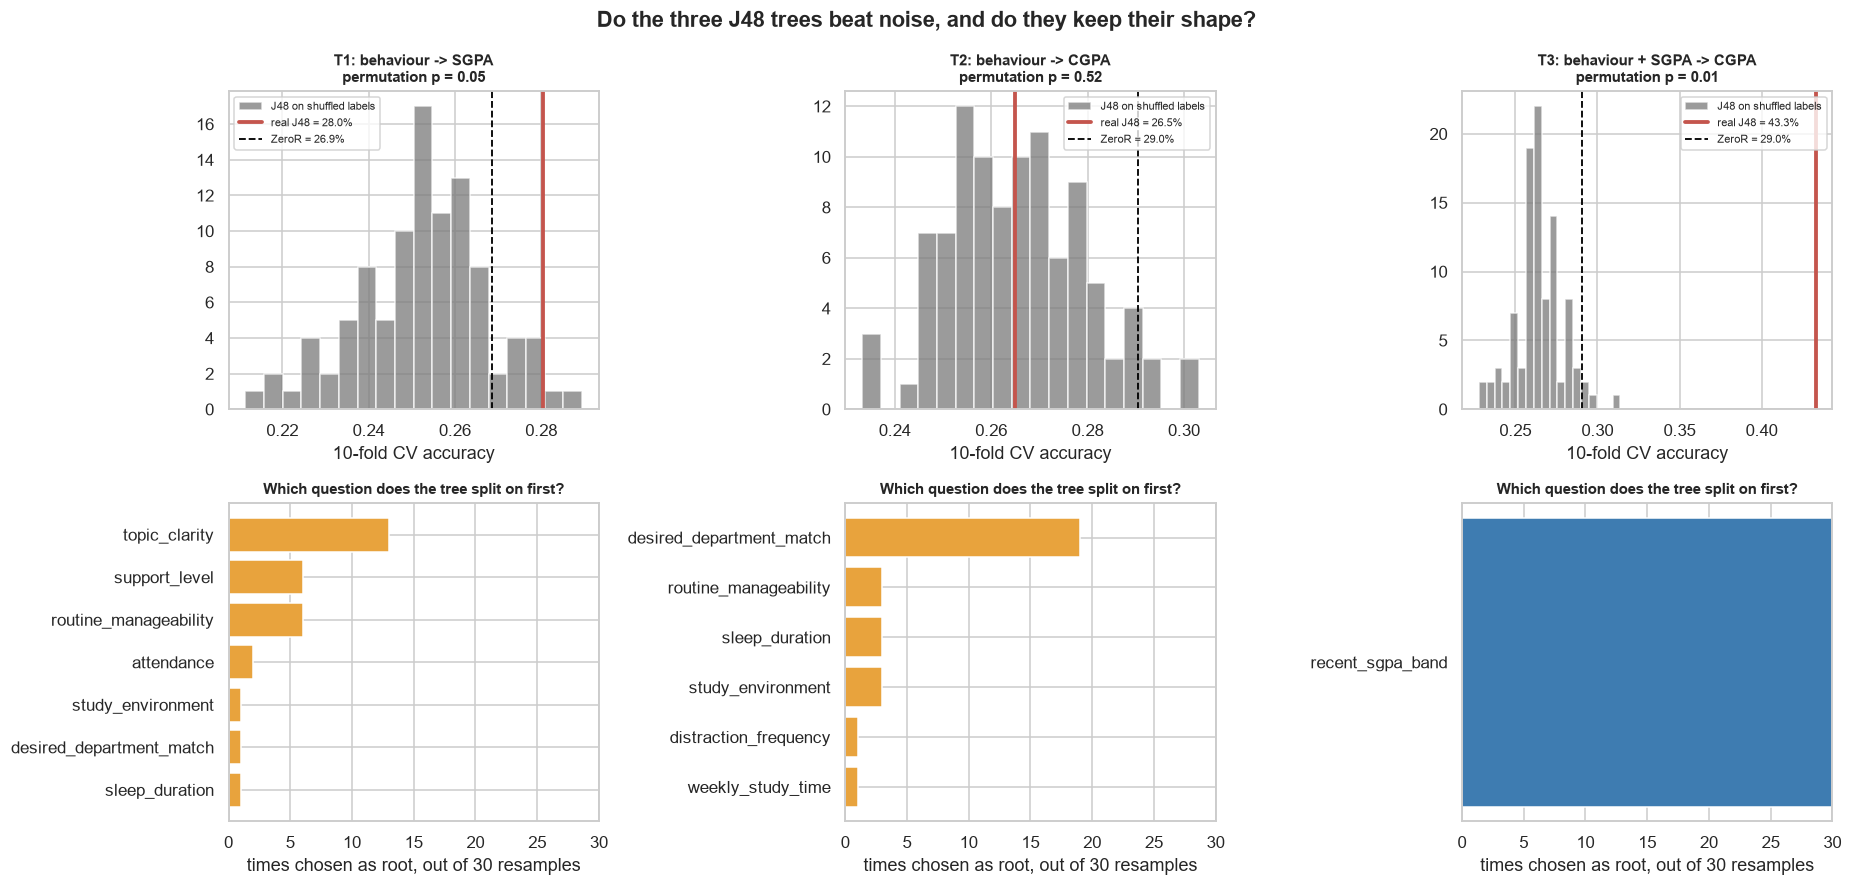

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(17, 8.2))
for col, tname in enumerate(TREES):
    d = tree_tbl[tree_tbl.tree == tname]
    real = d[d.kind == "real"].accuracy.iloc[0]
    zr = d[d.kind == "zeror"].accuracy.iloc[0]
    ax = axes[0, col]
    ax.hist(d[d.kind == "perm"].accuracy, bins=18, color=PALETTE[5], alpha=.75, label="J48 on shuffled labels")
    ax.axvline(real, color=PALETTE[3], lw=2.5, label=f"real J48 = {real:.1%}")
    ax.axvline(zr, color="black", ls="--", lw=1.2, label=f"ZeroR = {zr:.1%}")
    ax.set_title(f"{tname}\npermutation p = {tree_summary.loc[tname, 'permutation p']:.2f}", fontsize=10)
    ax.set_xlabel("10-fold CV accuracy"); ax.legend(fontsize=7.5)
    ax = axes[1, col]
    roots = d[d.kind == "subsample"].root.value_counts()
    ax.barh(roots.index[::-1], roots.values[::-1], color=PALETTE[0] if roots.size == 1 else PALETTE[1])
    ax.set_xlim(0, N_SUB); ax.set_xlabel(f"times chosen as root, out of {N_SUB} resamples")
    ax.set_title("Which question does the tree split on first?", fontsize=10)
plt.suptitle("Do the three J48 trees beat noise, and do they keep their shape?", fontweight="bold")
plt.tight_layout()
save_fig("a10_tree_meaningfulness")

**Verdict per tree.**

- **T3 (behaviour + recent SGPA -> CGPA) is real and stable.** 43.3% against a shuffled-label mean
  of 26.5% (p = 0.01, the smallest possible with 99 shuffles), and all 30 resampled trees split on
  recent SGPA first. Its rules — "if recent SGPA is C1, predict C1" — are meaningful, and also the
  least surprising: last semester predicts the cumulative grade.
- **T2 (behaviour -> CGPA) is indistinguishable from noise.** 26.5% is *below* ZeroR (29.0%) and
  exactly the shuffled-label mean (p = 0.52). Its first split is usually `desired_department_match`
  (19/30) — the strongest behavioural association in notebook `02` — so the tree finds the one weak
  real signal first, but everything under that split fits noise, and 6 different roots appear
  across 30 samples.
- **T1 (behaviour -> recent SGPA) is marginal at best.** It beats ZeroR by 1.1 points (28.0% vs
  26.9%) and the shuffled trees at p = 0.05 — the edge of significance — while 7 different root
  questions appear across 30 samples. Some weak signal; no stable rule structure.

**The deck's tree screenshot is T1.** Its root is `routine_manageability`, its second split
(`topic_clarity > 3 -> C0`) matches the deck's "SGPA rules" slide, and its leaves sum to 881 — one
80% training sample. That root appears in only 6 of our 30 resamples; `topic_clarity` is the root in
13. The rule "if almost everything is clear after class, predict the lowest band" is one sample's
accident, not a finding. It is a legitimate WEKA output — present it as an example of what a tree
does with weak signal, not as a rule to interpret.

### 8.2 Tree size — why the deck shows 268–315 leaves

WEKA's default J48 needs only 2 students per leaf (`-M 2`) and grows trees with hundreds of
leaves on this data — each rule backed by a handful of students. The `-M 40` setting the team
used for the displayed trees is a sensible guard, and its effect is visible directly:

In [19]:
jobs = []
for M in [2, 5, 10, 20, 40, 80]:
    jobs.append(dict(name=f"E_T3_J48_M{M}_cv10", scheme=["weka.classifiers.trees.J48", "-C", "0.25", "-M", str(M)],
                     train=MAIN, M=M, data="T3 main"))
    jobs.append(dict(name=f"E_T3_J48_M{M}_full", scheme=["weka.classifiers.trees.J48", "-C", "0.25", "-M", str(M)],
                     train=MAIN, M=M, data="T3 main", keep_model=True))
    jobs.append(dict(name=f"E_T2_J48_M{M}_cv10", scheme=["weka.classifiers.trees.J48", "-C", "0.25", "-M", str(M)],
                     train=QUEST, M=M, data="T2 questionnaire"))
m_runs = W.run_many(jobs)
m_tbl = pd.DataFrame([{**r.row(), "leaves": r.extra.get("leaves")} for r in m_runs])
leaves = m_tbl[m_tbl.leaves.notna()].set_index("M").leaves
m_view = m_tbl[m_tbl.leaves.isna()].pivot_table(index="M", columns="data", values="accuracy")
m_view["T3 leaves"] = leaves
display(m_view.round(3))

data,T2 questionnaire,T3 main,T3 leaves
M,,,
2,0.261,0.380,242.0
5,0.288,0.410,64.0
10,0.291,0.441,34.0
20,0.295,0.438,13.0
40,0.265,0.433,7.0
80,0.278,0.456,4.0


With WEKA's default `-M 2`, T3 grows 242 leaves and cross-validates at 38.0%; at `-M 80` it has 4
leaves and reaches 45.6%. Larger minimum leaf sizes give smaller trees and *better* cross-validated
accuracy — the default tree is memorising individual students. This is why the deck's J48 CV figures
(38-40%) sit below ours: those runs used the default leaf size. The 4-leaf tree is simply one leaf
per SGPA band.

## 9. Check 7 — fixes, each one tested in WEKA

Every fix below starts from a stated cause, predicts what should change if the cause is real, and
is then measured. All runs: WEKA 10-fold stratified CV, repeated with seeds 1–3, confusion
matrices summed.

| Fix | Targets which cause | Predicted effect if the diagnosis is right |
|---|---|---|
| **F1 Cost-sensitive learning** | The model treats a 3-band miss like a 1-band miss | Far errors fall; accuracy may fall slightly |
| **F2 Clean training folds only** | Model learns wrong rules from contradictory rows | Small gain — test folds still contain unlearnable rows |
| **F3 Exclude the 6–7 Aug wave** | 455 rows answer SGPA/CGPA at random | Large gain in accuracy, large drop in far errors |
| **F4 F3 + target-free quality screen** | Careless answers outside the wave | A further small gain |
| **F5 F3 + cost-sensitive** | Remaining far errors | Fewest far errors |
| **Tuning** (500 trees, numeric SGPA) | "Maybe the model is under-powered" | Nothing — the limit is the data |

In [20]:
SEEDS = [1, 2, 3]
df["quality_screen"] = df.satisfaction_contradiction | (df.mahalanobis > df.mahalanobis.quantile(.95))
trusted = df[~df.burst].reset_index(drop=True)
burst = df[df.burst].reset_index(drop=True)
screened = df[~df.burst & ~df.quality_screen].reset_index(drop=True)
print(f"all rows: {len(df)} | 6-7 Aug wave: {len(burst)} | trusted: {len(trusted)} | "
      f"trusted + quality screen: {len(screened)} (screen removes {int((~df.burst & df.quality_screen).sum())} more)")

P_ALL = MAIN
P_TRUSTED = make_arff(trusted, "trusted_main_cgpa")
P_SCREENED = make_arff(screened, "trusted_screened_main_cgpa")
P_BURST = make_arff(burst, "burst_6_7_aug_main_cgpa")
P_ALL_FLAG = make_arff(df, "main_cgpa_1102_with_wave_flag",
                       extra={"wave_flag": (np.where(df.burst, "excluded", "kept"), ["kept", "excluded"])})

ONER = ["weka.classifiers.rules.OneR", "-B", "6"]
def cost_sensitive(base_scheme, kind="linear"):
    return ["weka.classifiers.meta.CostSensitiveClassifier", "-cost-matrix", W.cost_matrix(kind),
            "-M", "-S", "1", "-W", base_scheme[0]]
# FilteredClassifier: drop 'excluded' rows from TRAINING folds only (-F), then drop the flag column.
CLEAN_TRAIN_ONLY = ["weka.classifiers.meta.FilteredClassifier", "-F",
                    'weka.filters.MultiFilter -F "weka.filters.unsupervised.instance.RemoveWithValues -S 0.0 -C 14 -L 2 -F" '
                    '-F "weka.filters.unsupervised.attribute.Remove -R 14"',
                    "-W", "weka.classifiers.functions.SMO"]

FIXES = [
    # label, data label, scheme, path, base options
    ("ZeroR",                        "all rows", W.ZEROR, P_ALL, None),
    ("OneR (single best feature)",   "all rows", ONER, P_ALL, None),
    ("SMO — baseline",               "all rows", W.SMO, P_ALL, None),
    ("RandomForest — baseline",      "all rows", W.RF, P_ALL, None),
    ("F1 cost-sensitive RF",         "all rows", cost_sensitive(W.RF), P_ALL, W.RF[1:]),
    ("F2 SMO, clean training folds", "all rows", CLEAN_TRAIN_ONLY, P_ALL_FLAG, None),
    ("RF 500 trees, numeric SGPA",   "all rows", ["weka.classifiers.trees.RandomForest", "-I", "500", "-M", "5.0",
                                                  "-S", "1", "-num-slots", "1"], MAIN_NUM, None),
    ("ZeroR",                        "trusted", W.ZEROR, P_TRUSTED, None),
    ("OneR (single best feature)",   "trusted", ONER, P_TRUSTED, None),
    ("J48",                          "trusted", W.J48, P_TRUSTED, None),
    ("NaiveBayes",                   "trusted", W.NAIVE_BAYES, P_TRUSTED, None),
    ("Logistic",                     "trusted", W.LOGISTIC, P_TRUSTED, None),
    ("F3 SMO",                       "trusted", W.SMO, P_TRUSTED, None),
    ("F3 RandomForest",              "trusted", W.RF, P_TRUSTED, None),
    ("F5 cost-sensitive RF",         "trusted", cost_sensitive(W.RF), P_TRUSTED, W.RF[1:]),
    ("ZeroR",                        "trusted + screen", W.ZEROR, P_SCREENED, None),
    ("F4 SMO",                       "trusted + screen", W.SMO, P_SCREENED, None),
    ("F4 RandomForest",              "trusted + screen", W.RF, P_SCREENED, None),
]
jobs = []
for label, dlabel, scheme, path, base in FIXES:
    for s in SEEDS:
        jobs.append(dict(name=f"F_{tag(dlabel)}_{tag(label)}_s{s}", scheme=scheme, train=path, seed=s,
                         base=base, fix=label, data=dlabel))
groups = {}
for r in W.run_many(jobs):
    groups.setdefault((r.extra["data"], r.extra["fix"]), []).append(r)
fix_res = {k: pooled(v, " | ".join(k)) for k, v in groups.items()}
fix_tbl = pd.DataFrame([{**r.row(), "data": k[0], "fix": k[1]} for k, r in fix_res.items()])
fix_tbl["rows"] = fix_tbl.n // len(SEEDS)
fix_view = fix_tbl.set_index(["data", "fix"])[["rows", "accuracy", "acc_std", "kappa", "qwk", "far_rate", "within_1", "macro_f1"]]
display(fix_view.round(3))

all rows: 1102 | 6-7 Aug wave: 455 | trusted: 647 | trusted + quality screen: 606 (screen removes 41 more)


rows  accuracy  acc_std  kappa  \
data             fix                                                            
all rows         ZeroR                         1102     0.290    0.000  0.000   
                 OneR (single best feature)    1102     0.461    0.000  0.279   
                 SMO — baseline                1102     0.461    0.000  0.279   
                 RandomForest — baseline       1102     0.449    0.007  0.260   
                 F1 cost-sensitive RF          1102     0.425    0.008  0.210   
                 F2 SMO, clean training folds  1102     0.461    0.000  0.279   
                 RF 500 trees, numeric SGPA    1102     0.458    0.004  0.271   
trusted          ZeroR                          647     0.314    0.000  0.000   
                 OneR (single best feature)     647     0.611    0.000  0.476   
                 J48                            647     0.611    0.000  0.476   
                 NaiveBayes                     647     0.592    0.005  0.451   
                 Logistic                       647     0.607    0.001  0.471   
                 F3 SMO                         647     0.611    0.000  0.476   
                 F3 RandomForest                647     0.603    0.006  0.463   
                 F5 cost-sensitive RF           647     0.584    0.003  0.431   
trusted + screen ZeroR                          606     0.330    0.000  0.000   
                 F4 SMO                         606     0.622    0.001  0.488   
                 F4 RandomForest                606     0.605    0.007  0.463   

                                                 qwk  far_rate  within_1  \
data             fix                                                       
all rows         ZeroR                         0.000     0.223     0.777   
                 OneR (single best feature)    0.322     0.220     0.780   
                 SMO — baseline                0.322     0.220     0.780   
                 RandomForest — baseline       0.302     0.220     0.780   
                 F1 cost-sensitive RF          0.335     0.162     0.838   
                 F2 SMO, clean training folds  0.322     0.220     0.780   
                 RF 500 trees, numeric SGPA    0.325     0.211     0.789   
trusted          ZeroR                         0.000     0.216     0.784   
                 OneR (single best feature)    0.616     0.093     0.907   
                 J48                           0.616     0.093     0.907   
                 NaiveBayes                    0.578     0.108     0.892   
                 Logistic                      0.617     0.093     0.907   
                 F3 SMO                        0.616     0.093     0.907   
                 F3 RandomForest               0.589     0.101     0.899   
                 F5 cost-sensitive RF          0.618     0.080     0.920   
trusted + screen ZeroR                         0.000     0.201     0.799   
                 F4 SMO                        0.643     0.079     0.921   
                 F4 RandomForest               0.608     0.094     0.906   

                                               macro_f1  
data             fix                                     
all rows         ZeroR                            0.113  
                 OneR (single best feature)       0.460  
                 SMO — baseline                   0.460  
                 RandomForest — baseline          0.447  
                 F1 cost-sensitive RF             0.398  
                 F2 SMO, clean training folds     0.460  
                 RF 500 trees, numeric SGPA       0.456  
trusted          ZeroR                            0.119  
                 OneR (single best feature)       0.613  
                 J48                              0.613  
                 NaiveBayes                       0.593  
                 Logistic                         0.610  
                 F3 SMO                           0.613  
                 F3 RandomForest   

### 9.1 Guards — are we fooling ourselves?

Excluding rows and then reporting higher accuracy is exactly what a careless analysis looks like,
so F3 has to survive three attacks.

| Guard | The worry it answers |
|---|---|
| **G1 Remove 455 *random* rows** (10 draws) | "Accuracy went up only because the dataset got smaller." |
| **G2 Train on trusted rows, test on the 6–7 Aug wave** | "Those students are real, just harder." A model that works on everyone else should still beat ZeroR on them. |
| **G3 Remove the contradictory rows themselves** | "Excluding the wave is just a disguised way of deleting rows where SGPA ≠ CGPA." This is the openly circular version — a ceiling, not a fix. |

In [21]:
jobs = []
rng = np.random.default_rng(99)
for d in range(10):
    keep_idx = np.sort(rng.choice(len(df), len(trusted), replace=False))
    path = make_arff(df.iloc[keep_idx].reset_index(drop=True), f"_work/guard_random_drop_{d}")
    for mname, scheme in [("SMO", W.SMO), ("RandomForest", W.RF)]:
        jobs.append(dict(name=f"bulk/G1_random_drop{d}_{mname}", scheme=scheme, train=path, guard="G1 random 455 rows removed", model=mname))
for mname, scheme in [("ZeroR", W.ZEROR), ("SMO", W.SMO), ("RandomForest", W.RF)]:
    jobs.append(dict(name=f"G2_train_trusted_test_wave_{mname}", scheme=scheme, train=P_TRUSTED, test=P_BURST,
                     guard="G2 train trusted -> test 6-7 Aug wave", model=mname))
P_CONSISTENT = make_arff(df[~df.far_gap].reset_index(drop=True), "_work/guard_consistent_rows_only")
for mname, scheme in [("ZeroR", W.ZEROR), ("SMO", W.SMO)]:
    jobs.append(dict(name=f"G3_consistent_only_{mname}", scheme=scheme, train=P_CONSISTENT,
                     guard="G3 contradictory rows deleted (circular)", model=mname))
groups = {}
for r in W.run_many(jobs):
    groups.setdefault((r.extra["guard"], r.extra["model"]), []).append(r)
guard_res = {k: pooled(v, " | ".join(k)) for k, v in groups.items()}
guard_tbl = pd.DataFrame([{**r.row(), "guard": k[0], "model": k[1]} for k, r in guard_res.items()])
display(guard_tbl.set_index(["guard", "model"])[["n", "accuracy", "acc_std", "kappa", "qwk", "far_rate"]].round(3))

n  accuracy  \
guard                                    model                          
G1 random 455 rows removed               SMO           6470     0.460   
                                         RandomForest  6470     0.447   
G2 train trusted -> test 6-7 Aug wave    ZeroR          455     0.257   
                                         SMO            455     0.248   
                                         RandomForest   455     0.240   
G3 contradictory rows deleted (circular) ZeroR          860     0.314   
                                         SMO            860     0.591   

                                                       acc_std  kappa    qwk  \
guard                                    model                                 
G1 random 455 rows removed               SMO             0.010  0.278  0.321   
                                         RandomForest    0.013  0.257  0.294   
G2 train trusted -> test 6-7 Aug wave    ZeroR           0.000  0.000  0.000   
                                         SMO             0.000 -0.001 -0.041   
                                         RandomForest    0.000 -0.014 -0.046   
G3 contradictory rows deleted (circular) ZeroR           0.000  0.000  0.000   
                                         SMO             0.000  0.446  0.803   

                                                       far_rate  
guard                                    model                   
G1 random 455 rows removed               SMO              0.222  
                                         RandomForest     0.218  
G2 train trusted -> test 6-7 Aug wave    ZeroR            0.233  
                                         SMO              0.400  
                                         RandomForest     0.382  
G3 contradictory rows deleted (circular) ZeroR            0.201  
                                         SMO              0.000

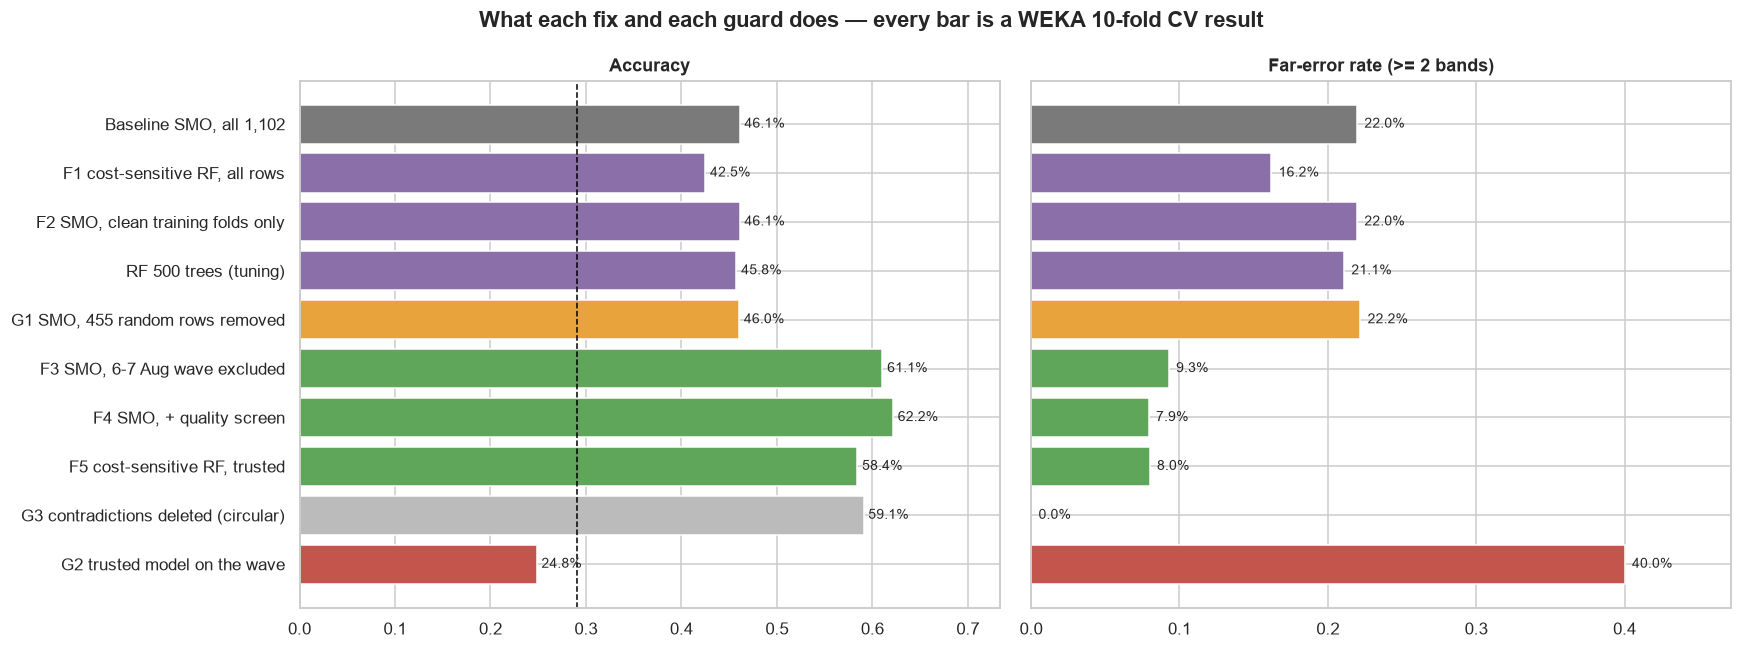

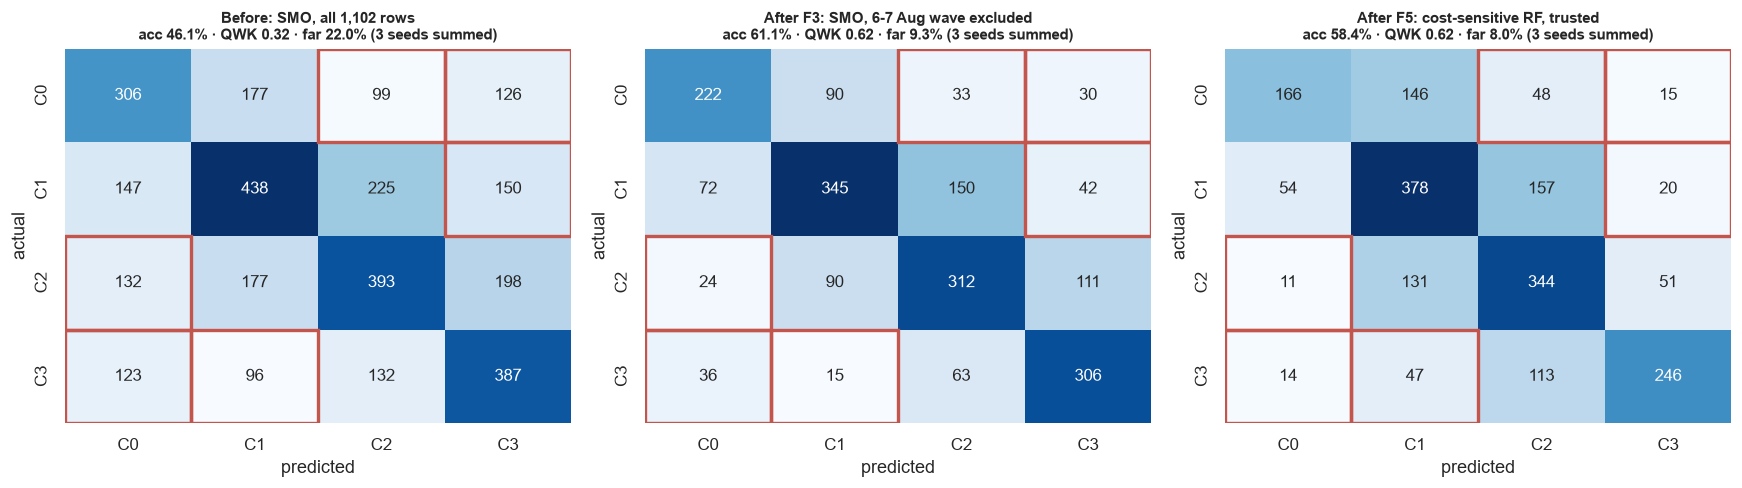

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
bars = [
    ("Baseline SMO, all 1,102",               fix_res[("all rows", "SMO — baseline")], PALETTE[5]),
    ("F1 cost-sensitive RF, all rows",        fix_res[("all rows", "F1 cost-sensitive RF")], PALETTE[4]),
    ("F2 SMO, clean training folds only",     fix_res[("all rows", "F2 SMO, clean training folds")], PALETTE[4]),
    ("RF 500 trees (tuning)",                 fix_res[("all rows", "RF 500 trees, numeric SGPA")], PALETTE[4]),
    ("G1 SMO, 455 random rows removed",       guard_res[("G1 random 455 rows removed", "SMO")], PALETTE[1]),
    ("F3 SMO, 6-7 Aug wave excluded",         fix_res[("trusted", "F3 SMO")], PALETTE[2]),
    ("F4 SMO, + quality screen",              fix_res[("trusted + screen", "F4 SMO")], PALETTE[2]),
    ("F5 cost-sensitive RF, trusted",         fix_res[("trusted", "F5 cost-sensitive RF")], PALETTE[2]),
    ("G3 contradictions deleted (circular)",  guard_res[("G3 contradictory rows deleted (circular)", "SMO")], "#BBBBBB"),
    ("G2 trusted model on the wave",          guard_res[("G2 train trusted -> test 6-7 Aug wave", "SMO")], PALETTE[3]),
]
y = np.arange(len(bars))
for ax, metric, title in [(axes[0], "accuracy", "Accuracy"), (axes[1], "far_rate", "Far-error rate (>= 2 bands)")]:
    vals = [getattr(r, metric) for _, r, _ in bars]
    ax.barh(y, vals, color=[c for *_, c in bars])
    for yi, v in zip(y, vals):
        ax.text(v + .005, yi, f"{v:.1%}", va="center", fontsize=9)
    ax.set_yticks(y); ax.set_yticklabels([] if ax is axes[1] else [b[0] for b in bars]); ax.invert_yaxis()
    ax.set_title(title); ax.set_xlim(0, max(vals) * 1.18)
axes[0].axvline(fix_res[("all rows", "ZeroR")].accuracy, ls="--", c="black", lw=1)
plt.suptitle("What each fix and each guard does — every bar is a WEKA 10-fold CV result", fontweight="bold")
plt.tight_layout()
save_fig("a11_fixes_and_guards")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, key, title in [(axes[0], ("all rows", "SMO — baseline"), "Before: SMO, all 1,102 rows"),
                       (axes[1], ("trusted", "F3 SMO"), "After F3: SMO, 6-7 Aug wave excluded"),
                       (axes[2], ("trusted", "F5 cost-sensitive RF"), "After F5: cost-sensitive RF, trusted")]:
    r = fix_res[key]
    cm_plot(ax, r.cm, f"{title}\nacc {r.accuracy:.1%} · QWK {r.qwk:.2f} · far {r.far_rate:.1%} (3 seeds summed)")
plt.tight_layout()
save_fig("a12_confusion_before_after")

**Reading the results.**

- **F1 (cost-sensitive) does what it says, at a price.** Far errors fall from 22.0% to 16.2%, but
  Random Forest accuracy falls from 44.9% to 42.5%, partly because predictions are pulled toward the
  middle bands. It treats the symptom.
- **F2 (clean training folds) changes nothing — 46.1% before and after — and that is informative.**
  A model trained on clean rows must still be *scored* on the 6-7 August rows, and nobody can
  predict an answer picked at random. The noise caps the measurable accuracy.
- **Tuning does nothing** (500 trees: 45.8%). The model is not the bottleneck.
- **F3 (excluding the wave) is the large, genuine improvement:** SMO 46.1% -> 61.1%, kappa 0.279 ->
  0.476, QWK 0.322 -> 0.616, far errors 22.0% -> 9.3%. It survives all three guards:
  - **G1:** removing 455 *random* rows leaves SMO at 46.0%. The gain is about *which* rows, not
    *how many*.
  - **G2:** a model trained on the trusted students scores 24.8% on the wave — below the wave's own
    ZeroR (25.7%). These answers are not "harder"; they are unlearnable.
  - **G3:** deleting the contradictory rows directly — the circular shortcut — reaches 59.1%,
    **below** F3. Excluding the wave is not a disguised way of keeping only consistent students.
- **F4** (+ target-free quality screen) reaches 62.2% with 7.9% far errors; **F5** (cost-sensitive
  RF on trusted data) brings far errors to 8.0% at 58.4% accuracy.

**What "61%" actually is — say this in the viva.** OneR, a single rule on recent SGPA, scores
**exactly** the same as SMO, J48 and Logistic — on all rows (46.1%) and on trusted rows (61.1%). The
J48 tree trained on trusted data has four leaves, one per SGPA band. The models are learning
*CGPA band = recent SGPA band*, and the twelve behaviour answers add nothing to accuracy. Removing
the wave did not make behaviour predictive; it made the SGPA-CGPA relationship reliable again. §11
shows what it *did* do for the behaviour questions.

**Recommended configuration**

| Decision | Choice | Why |
|---|---|---|
| Rows | Exclude KUET semester-7 responses submitted on 6-7 Aug 2026 (455 rows); **always show the full-data result beside it** | §4 evidence; survives guards G1-G3 |
| Features | 12 questionnaire items (numeric 0-4) + recent SGPA (**nominal**) | §7.1: nominal SGPA is worth ~9 points to SMO/Logistic |
| Baselines to show | ZeroR **and OneR** | OneR reveals that the accuracy is the SGPA rule |
| Model to headline | **SMO** (joint best on trusted data with J48/Logistic; identical across seeds) | §9 |
| Readable rules | **J48 -M 40** | on trusted data it is exactly the four SGPA rules — honest and easy to explain |
| Fewest far errors | CostSensitiveClassifier (linear cost) around RandomForest | §9, F5 |
| Evaluation | **10-fold stratified CV** | §6: a single split varies by up to ±7 points |
| Metrics | accuracy, kappa, **QWK**, far-error rate, confusion matrix | the class is ordinal; far errors are what the teacher asked about |

The team's deck also shows one train/test split. We export a **fixed, stratified 80/20 split**
(seed 42) of both the full and the trusted data, so the Explorer's *Supplied test set* option
reproduces these exact numbers and confusion matrices.

all      train 881  test 221  test class counts [47, 64, 60, 50]
trusted  train 517  test 130  test class counts [25, 41, 36, 28]


accuracy         far_rate            qwk        
data                  all trusted      all trusted    all trusted
model                                                            
CostSensitive RF    0.394   0.592    0.136   0.085  0.350   0.640
J48                 0.498   0.615    0.186   0.100  0.447   0.644
Logistic            0.489   0.608    0.204   0.115  0.389   0.621
NaiveBayes          0.498   0.600    0.204   0.108  0.383   0.630
OneR                0.493   0.615    0.204   0.100  0.417   0.644
RandomForest        0.471   0.623    0.195   0.100  0.389   0.643
SMO                 0.493   0.615    0.204   0.100  0.417   0.644
ZeroR               0.290   0.315    0.226   0.215  0.000   0.000

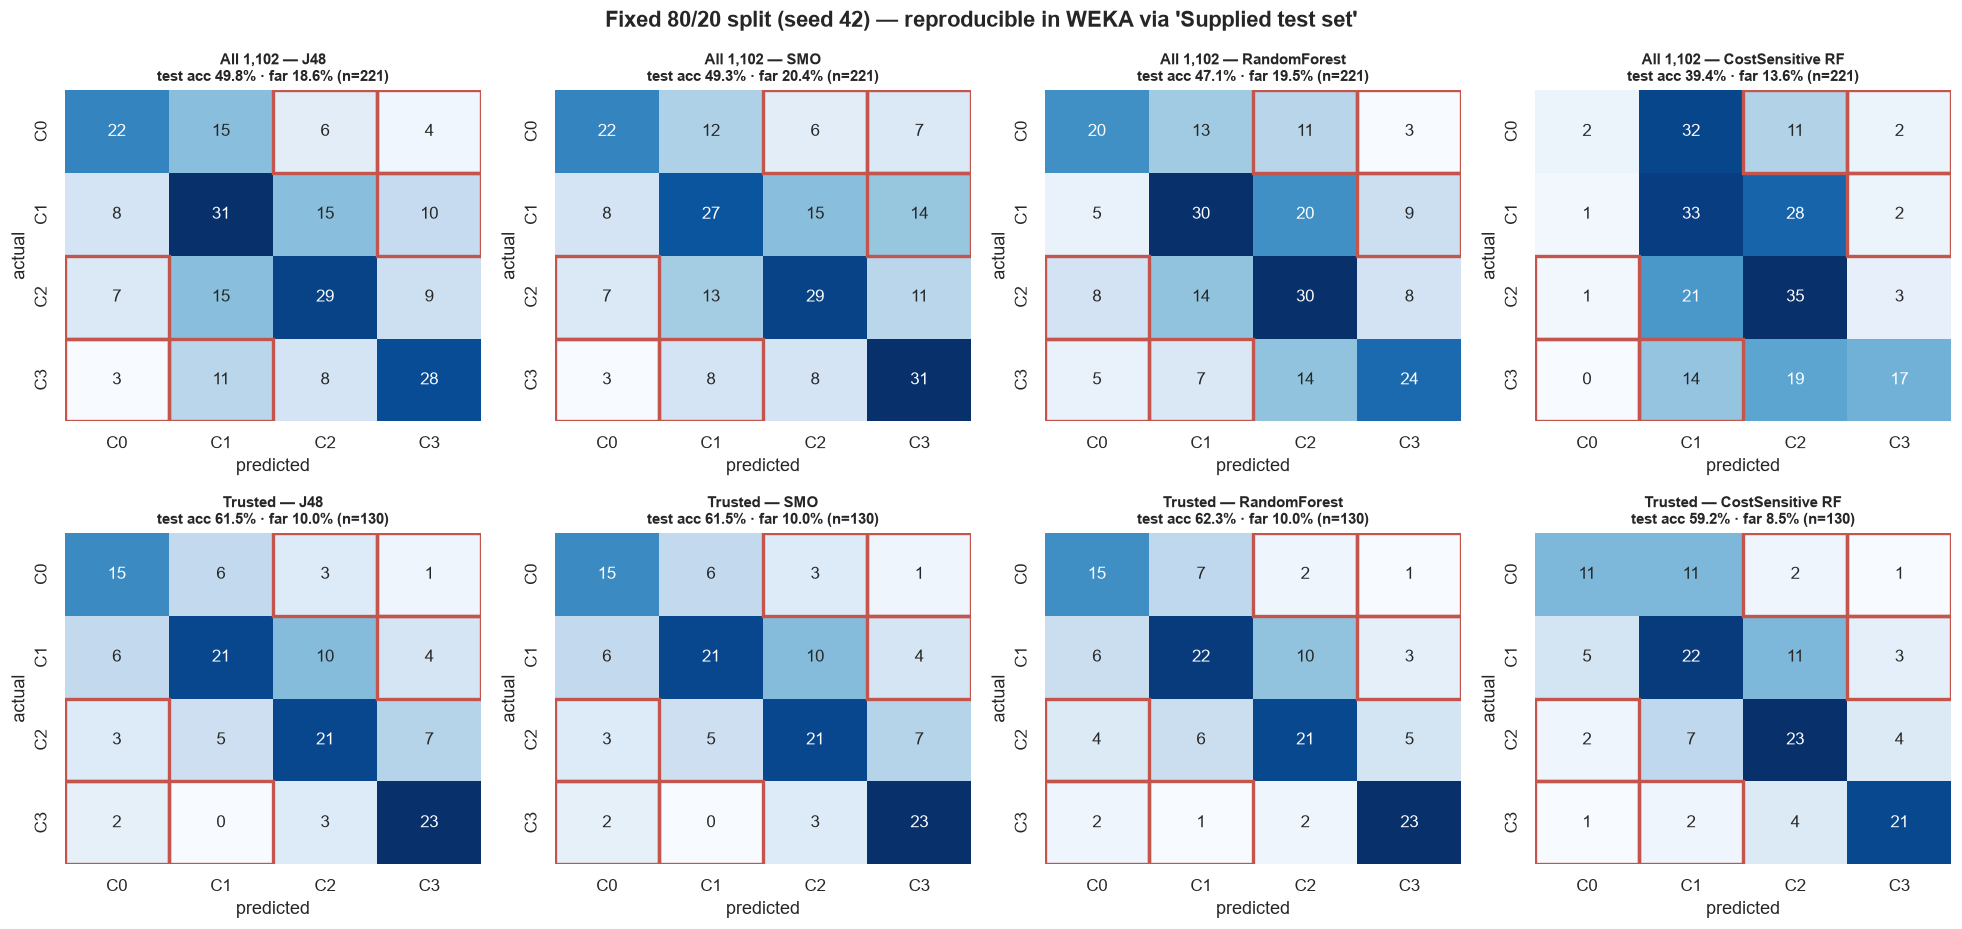

J48 -M 40 trained on the trusted 80% split:
J48 pruned tree
------------------

recent_sgpa_band = C0: C0 (92.0/33.0)
recent_sgpa_band = C1: C1 (148.0/54.0)
recent_sgpa_band = C2: C2 (149.0/66.0)
recent_sgpa_band = C3: C3 (128.0/49.0)




In [23]:
from sklearn.model_selection import train_test_split
SPLIT_FILES = {}
for label, frame in [("all", df), ("trusted", trusted)]:
    tr, te = train_test_split(frame, test_size=.2, stratify=frame.target_code, random_state=42)
    SPLIT_FILES[label] = (make_arff(tr.reset_index(drop=True), f"split_{label}_train80"),
                          make_arff(te.reset_index(drop=True), f"split_{label}_test20"))
    print(f"{label:<8} train {len(tr)}  test {len(te)}  test class counts {te.target_code.value_counts().sort_index().tolist()}")

HOLDOUT_MODELS = {"ZeroR": W.ZEROR, "OneR": ONER, "J48": W.J48, "NaiveBayes": W.NAIVE_BAYES,
                  "Logistic": W.LOGISTIC, "SMO": W.SMO, "RandomForest": W.RF}
jobs = []
for label, (ptr, pte) in SPLIT_FILES.items():
    for mname, scheme in HOLDOUT_MODELS.items():
        jobs.append(dict(name=f"H_{label}_{mname}_supplied_test", scheme=scheme, train=ptr, test=pte,
                         data=label, model=mname, keep_model=(mname == "J48")))
    jobs.append(dict(name=f"H_{label}_CostSensitiveRF_supplied_test", scheme=cost_sensitive(W.RF), train=ptr,
                     test=pte, base=W.RF[1:], data=label, model="CostSensitive RF"))
hold = {(r.extra["data"], r.extra["model"]): r for r in W.run_many(jobs)}
hold_tbl = pd.DataFrame([{**r.row(), "data": k[0], "model": k[1]} for k, r in hold.items()])
display(hold_tbl.pivot_table(index="model", columns="data", values=["accuracy", "qwk", "far_rate"]).round(3))

fig, axes = plt.subplots(2, 4, figsize=(18, 8.6))
for row, label in enumerate(["all", "trusted"]):
    for ax, m in zip(axes[row], ["J48", "SMO", "RandomForest", "CostSensitive RF"]):
        r = hold[(label, m)]
        cm_plot(ax, r.cm, f"{'All 1,102' if label == 'all' else 'Trusted'} — {m}\ntest acc {r.accuracy:.1%} · far {r.far_rate:.1%} (n={r.n})")
plt.suptitle("Fixed 80/20 split (seed 42) — reproducible in WEKA via 'Supplied test set'", fontweight="bold")
plt.tight_layout()
save_fig("a13_holdout_confusion_matrices")

tree_text = hold[("trusted", "J48")].log.split("J48 pruned tree", 1)[1].split("Number of Leaves", 1)[0]
print("J48 -M 40 trained on the trusted 80% split:\nJ48 pruned tree" + tree_text)

The trusted split's test set is small (130 students), so its accuracy carries a few points of
luck either way — which is exactly why §9's cross-validated numbers are the headline and this
split is the demonstration.

## 11. Pipeline A revisited — do the behaviour findings change without the wave?

Excluding the wave was decided from the SGPA–CGPA relationship alone. The **behaviour–CGPA**
associations played no part in that decision, so re-testing them on trusted data is a fair,
non-circular check. If the wave was random noise, it should have been *diluting* real behaviour
associations — and removing it should make them stronger, not weaker.

,rho all,q all,rho trusted,q trusted,rho 6-7 Aug wave,q wave
feature,,,,,,
desired_department_match,0.1166,0.0013,0.1594,0.0006,0.0677,0.4321
attendance,0.0880,0.0162,0.1412,0.0019,0.0214,0.8183
weekly_study_time,0.0677,0.0736,0.1222,0.0074,-0.0049,0.9995
routine_manageability,0.0391,0.3564,0.1034,0.0202,-0.0193,0.8183
support_level,0.0542,0.1729,0.1011,0.0202,0.0000,0.9995
topic_clarity,0.0380,0.3564,0.0939,0.0290,-0.0245,0.8183
study_environment,0.0179,0.6624,0.0870,0.0404,-0.0598,0.4321
study_style,-0.0054,0.8573,0.0570,0.1773,-0.0703,0.4321
sleep_duration,0.0299,0.4832,0.0078,0.8435,0.0563,0.4321


features significant after BH correction (q < 0.05):
  all 1,102   : 3 of 12  ['attendance', 'desired_department_match', 'weekly_responsibilities']
  trusted     : 8 of 12  ['attendance', 'desired_department_match', 'routine_manageability', 'study_environment', 'support_level', 'topic_clarity', 'weekly_responsibilities', 'weekly_study_time']
  6-7 Aug wave: 0 of 12  []


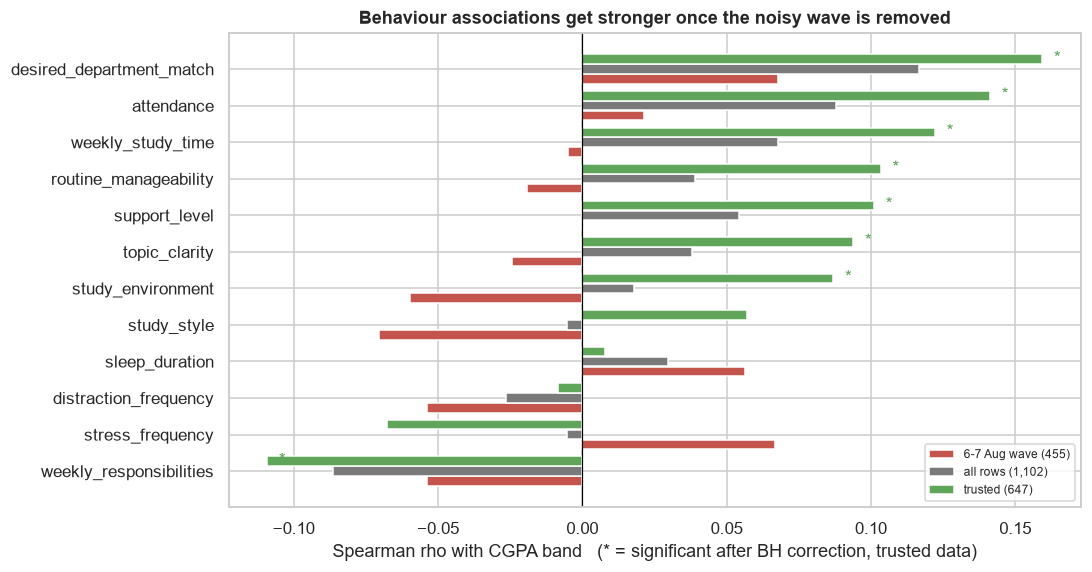

accuracy          kappa        
data              all trusted    all trusted
model                                       
J48             0.284   0.305  0.033   0.039
RandomForest    0.320   0.374  0.081   0.141
SMO             0.284   0.315  0.009   0.030
ZeroR           0.290   0.314  0.000   0.000

In [24]:
def assoc(frame):
    rows = []
    for i in ITEMS:
        rho, p = stats.spearmanr(frame[i + "_code"], frame.target_code)
        rows.append({"feature": i, "rho": rho, "p": p})
    t = pd.DataFrame(rows).sort_values("p").reset_index(drop=True)
    q = t.p * len(t) / (t.index + 1)
    t["q_BH"] = q[::-1].cummin()[::-1].clip(upper=1)            # Benjamini-Hochberg, correct direction
    return t.set_index("feature")

a_all, a_tr, a_wave = assoc(df), assoc(trusted), assoc(burst)
assoc_tbl = pd.DataFrame({
    "rho all": a_all.rho, "q all": a_all.q_BH,
    "rho trusted": a_tr.rho, "q trusted": a_tr.q_BH,
    "rho 6-7 Aug wave": a_wave.rho, "q wave": a_wave.q_BH,
}).sort_values("rho trusted", ascending=False)
display(assoc_tbl.round(4))
print("features significant after BH correction (q < 0.05):")
for name, t in [("all 1,102", a_all), ("trusted", a_tr), ("6-7 Aug wave", a_wave)]:
    print(f"  {name:<12}: {int((t.q_BH < .05).sum())} of {len(t)}  {sorted(t.index[t.q_BH < .05])}")

fig, ax = plt.subplots(figsize=(10, 5.6))
order = assoc_tbl.index[::-1]
yy = np.arange(len(order))
ax.barh(yy - .27, assoc_tbl.loc[order, "rho 6-7 Aug wave"], height=.26, color=PALETTE[3], label="6-7 Aug wave (455)")
ax.barh(yy, assoc_tbl.loc[order, "rho all"], height=.26, color=PALETTE[5], label="all rows (1,102)")
ax.barh(yy + .27, assoc_tbl.loc[order, "rho trusted"], height=.26, color=PALETTE[2], label="trusted (647)")
for yi, f in zip(yy, order):
    if assoc_tbl.loc[f, "q trusted"] < .05:
        ax.text(assoc_tbl.loc[f, "rho trusted"] + .004, yi + .27, "*", va="center", fontsize=12, color=PALETTE[2])
ax.set_yticks(yy); ax.set_yticklabels(order)
ax.axvline(0, c="black", lw=.8)
ax.set_xlabel("Spearman rho with CGPA band   (* = significant after BH correction, trusted data)")
ax.set_title("Behaviour associations get stronger once the noisy wave is removed")
ax.legend(fontsize=8, loc="lower right")
save_fig("a14_behaviour_associations_trusted")

jobs = []
for label, frame in [("all", df), ("trusted", trusted)]:
    path = make_arff(frame, f"_work/quest_{label}", with_sgpa=False)
    for mname, scheme in [("ZeroR", W.ZEROR), ("RandomForest", W.RF), ("SMO", W.SMO), ("J48", W.J48)]:
        for s in SEEDS:
            jobs.append(dict(name=f"I_quest_{label}_{mname}_s{s}", scheme=scheme, train=path, seed=s, data=label, model=mname))
groups = {}
for r in W.run_many(jobs):
    groups.setdefault((r.extra["data"], r.extra["model"]), []).append(r)
quest_res = {k: pooled(v, " | ".join(k)) for k, v in groups.items()}
display(pd.DataFrame([{**r.row(), "data": k[0], "model": k[1]} for k, r in quest_res.items()])
        .pivot_table(index="model", columns="data", values=["accuracy", "kappa"]).round(3))

**The prediction holds.** Behaviour items significant after Benjamini-Hochberg correction go from
**3 of 12** on all rows to **8 of 12** on trusted rows — and **0 of 12** inside the wave. The
associations get stronger (desired department rho 0.117 -> 0.159, attendance 0.088 -> 0.141, weekly
study time 0.068 -> 0.122), and effects notebook `02` called too weak to claim — study time, routine
manageability, support, topic clarity, study environment — become measurable once the random
answers are gone.

Two things did **not** change, and both belong in the report:

1. Every association is still **small** (largest rho = 0.16). Behaviour is associated with CGPA;
   it does not determine it.
2. The **behaviour-only model** improves only modestly: Random Forest 37.4% against a 31.4% floor
   on trusted data (32.0% vs 29.0% on all rows). Predicting a grade from habits alone remains hard.

### 11.1 Replacement data for the deck's per-question CGPA charts (slides 23-34)

The deck shows, for each of the 12 questions, the CGPA-band mix of students who chose each answer.
On all 1,102 rows those bars look almost the same whichever answer was chosen — partly because 455
of the students answered the GPA questions at random, which pulls every bar toward the same mix.
This cell writes the same breakdown for all rows *and* for trusted rows, so the charts can be
rebuilt from verified numbers.

,question,data,option_code,option,n,C0 %,C1 %,C2 %,C3 %
10,attendance,all,0,Less than 40%,10,30.0,20.0,20.0,30.0
11,attendance,all,1,40-59%,23,26.1,30.4,26.1,17.4
12,attendance,all,2,60-74%,276,24.6,29.3,28.6,17.4
13,attendance,all,3,75-89%,379,21.4,31.7,25.1,21.9
14,attendance,all,4,90% or more,414,18.8,26.6,28.5,26.1
15,attendance,trusted,0,Less than 40%,1,0.0,0.0,100.0,0.0
16,attendance,trusted,1,40-59%,11,27.3,36.4,18.2,18.2
17,attendance,trusted,2,60-74%,142,23.2,34.5,26.1,16.2
18,attendance,trusted,3,75-89%,234,20.1,34.2,29.1,16.7
19,attendance,trusted,4,90% or more,259,16.2,27.0,27.4,29.3


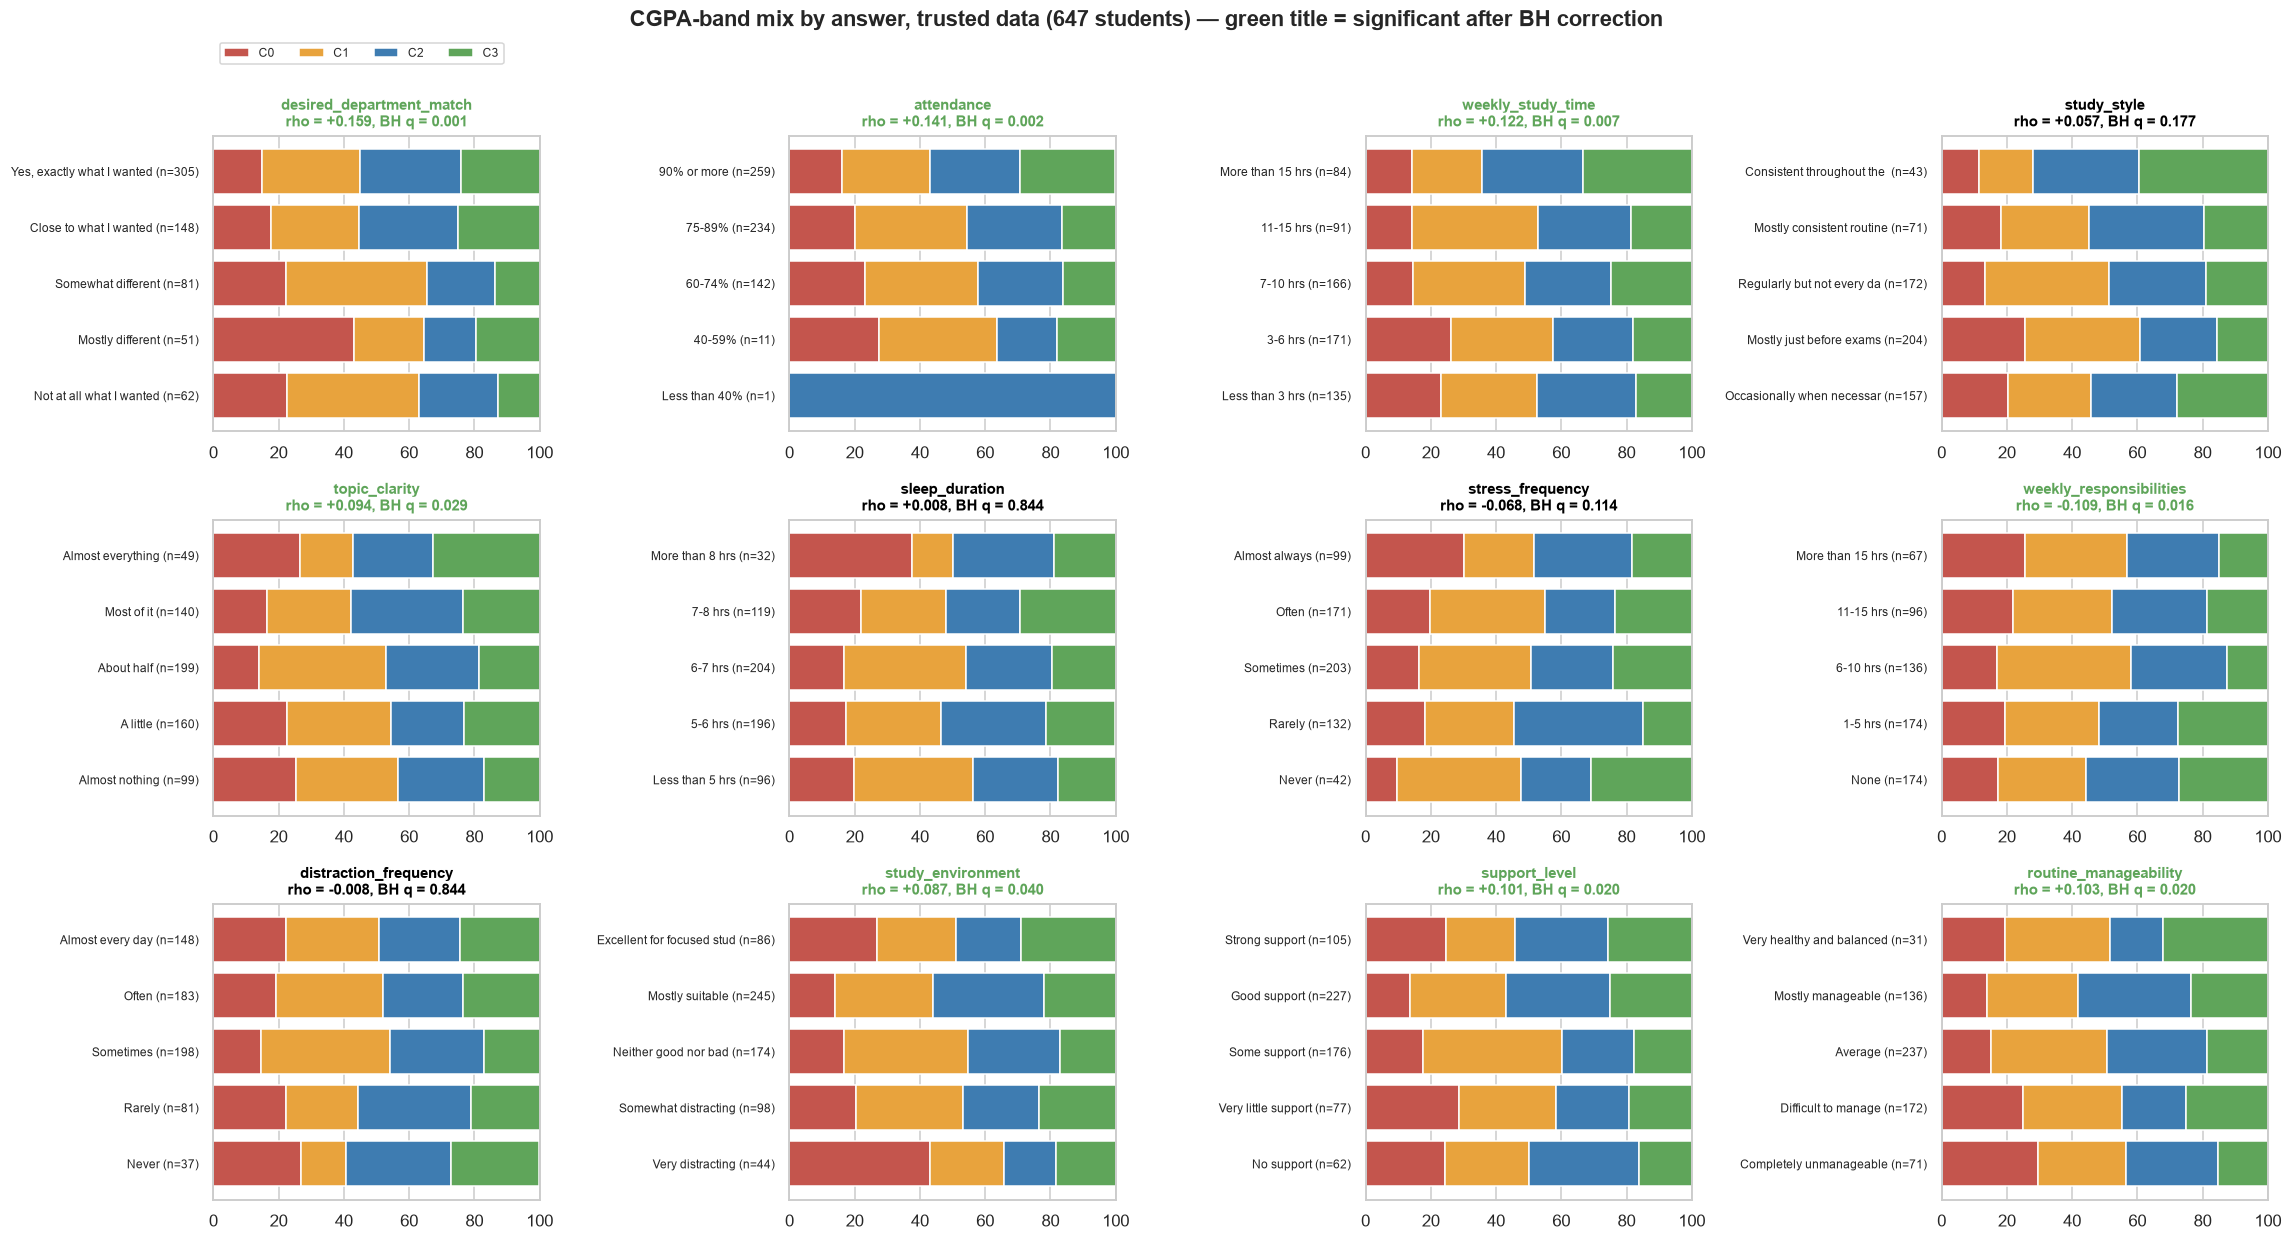

In [25]:
opt_rows = []
for item in ITEMS:
    for label, frame in [("all", df), ("trusted", trusted)]:
        for code, grp in frame.groupby(item + "_code"):
            shares = grp.target_code.value_counts(normalize=True).reindex(range(4), fill_value=0) * 100
            opt_rows.append({"question": item, "data": label, "option_code": int(code),
                             "option": grp[item].iloc[0] if pd.notna(grp[item].iloc[0]) else "None",  # pandas reads the answer None as NaN
                             "n": len(grp),
                             "C0 %": shares[0], "C1 %": shares[1], "C2 %": shares[2], "C3 %": shares[3]})
option_tbl = pd.DataFrame(opt_rows).round(1)
(ROOT / "docs" / "anomaly_tables").mkdir(exist_ok=True)
option_tbl.to_csv(ROOT / "docs" / "anomaly_tables" / "question_option_cgpa_mix_all_vs_trusted.csv", index=False)
display(option_tbl[option_tbl.question == "attendance"])

fig, axes = plt.subplots(3, 4, figsize=(21, 11.5))
band_cols = [PALETTE[3], PALETTE[1], PALETTE[0], PALETTE[2]]
for ax, item in zip(axes.ravel(), ITEMS):
    d = option_tbl[(option_tbl.question == item) & (option_tbl.data == "trusted")].sort_values("option_code")
    left = np.zeros(len(d))
    for b, col in zip(["C0 %", "C1 %", "C2 %", "C3 %"], band_cols):
        ax.barh(range(len(d)), d[b].values, left=left, color=col, label=b.replace(" %", ""))
        left += d[b].values
    ax.set_yticks(range(len(d)))
    ax.set_yticklabels([f"{str(o)[:26]} (n={n})" for o, n in zip(d.option, d.n)], fontsize=8)
    r = a_tr.loc[item]
    ax.set_title(f"{item}\nrho = {r.rho:+.3f}, BH q = {r.q_BH:.3f}", fontsize=10,
                 color=PALETTE[2] if r.q_BH < .05 else "black")
    ax.set_xlim(0, 100)
axes[0, 0].legend(ncol=4, fontsize=8, loc="lower left", bbox_to_anchor=(0, 1.22))
plt.suptitle("CGPA-band mix by answer, trusted data (647 students) — green title = significant after BH correction",
             fontweight="bold")
plt.tight_layout()
save_fig("a15_question_option_cgpa_mix_trusted")

## 12. Export and summary

Everything the report and the presentation quote is written to `docs/`, so nothing has to be
copied by hand from this notebook.

In [26]:
TABLE_DIR = ROOT / "docs" / "anomaly_tables"
TABLE_DIR.mkdir(exist_ok=True)
coh.to_csv(TABLE_DIR / "cohort_sgpa_cgpa_consistency.csv")
daily.to_csv(TABLE_DIR / "kuet_sem7_daily_contradiction.csv")
tests.to_csv(TABLE_DIR / "careless_indicator_tests.csv", index=False)
sub_tbl.to_csv(TABLE_DIR / "subsets_weka.csv", index=False)
eval_tbl.to_csv(TABLE_DIR / "evaluation_schemes_weka.csv", index=False)
spread.to_csv(TABLE_DIR / "evaluation_spread_weka.csv")
weight_tbl.to_csv(TABLE_DIR / "feature_weights_weka.csv", index=False)
topk_tbl.to_csv(TABLE_DIR / "attribute_selection_weka.csv", index=False)
enc_tbl.to_csv(TABLE_DIR / "sgpa_encoding_weka.csv", index=False)
tree_summary.to_csv(TABLE_DIR / "tree_meaningfulness_weka.csv")
m_view.to_csv(TABLE_DIR / "j48_leaf_size_weka.csv")
fix_tbl.to_csv(TABLE_DIR / "fixes_weka.csv", index=False)
guard_tbl.to_csv(TABLE_DIR / "guards_weka.csv", index=False)
hold_tbl.to_csv(TABLE_DIR / "holdout_supplied_test_weka.csv", index=False)
assoc_tbl.to_csv(TABLE_DIR / "behaviour_associations_all_trusted_wave.csv")

def cm_list(r):
    return r.cm.astype(int).tolist()

def brief(r):
    return {"accuracy": round(r.accuracy, 4), "kappa": round(r.kappa, 4), "qwk": round(r.qwk, 4),
            "far_rate": round(r.far_rate, 4), "within_1": round(r.within_one, 4),
            "macro_f1": round(r.macro_f1, 4), "confusion_matrix": cm_list(r)}

summary = {
    "rows": {"weka_base": len(df), "wave_6_7_aug": len(burst), "trusted": len(trusted), "trusted_screened": len(screened)},
    "anomaly": {"baseline_rf": brief(base_rf), "baseline_smo": brief(base_smo), "zeror": brief(base_zr),
                "far_errors_on_contradictory_students_share": round(float(pred.loc[pred.far_error, "far_gap"].mean()), 4),
                "contradictory_students_share": round(float(pred.far_gap.mean()), 4),
                "rf_acc_consistent_students": round(float(acc_consistent), 4),
                "rf_acc_contradictory_students": round(float(acc_contra), 4)},
    "cohorts": coh.round(4).reset_index().to_dict("records"),
    "wave": {"pre": {"n": len(pre), "far_gap": round(float(pre.far_gap.mean()), 4)},
             "wave": {"n": len(burst), "far_gap": round(float(burst.far_gap.mean()), 4)},
             "post": {"n": len(post), "far_gap": round(float(post.far_gap.mean()), 4)}},
    "careless_tests": tests.round(6).to_dict("records"),
    "subsets_smo_rf_zeror": {n: {m: brief(subset_res[(n, "main", m)]) | {"acc_std": round(subset_res[(n, "main", m)].extra["acc_std"], 4)}
                                 for m in ["ZeroR", "RandomForest", "SMO", "J48"]} for n in SUBSETS},
    "evaluation_spread": spread.round(4).reset_index().to_dict("records"),
    "trees": tree_summary.round(4).reset_index().to_dict("records"),
    "fixes": {f"{k[0]} | {k[1]}": brief(r) for k, r in fix_res.items()},
    "guards": {f"{k[0]} | {k[1]}": brief(r) for k, r in guard_res.items()},
    "holdout": {f"{k[0]} | {k[1]}": brief(r) | {"n_test": r.n} for k, r in hold.items()},
    "behaviour_significant_bh": {n: sorted(t.index[t.q_BH < .05]) for n, t in
                                 [("all", a_all), ("trusted", a_tr), ("wave", a_wave)]},
}
(ROOT / "docs" / "anomaly_results.json").write_text(json.dumps(summary, indent=2, default=float), encoding="utf-8")

logs = sorted(p.relative_to(ROOT).as_posix() for p in W.RUN_DIR.glob("*.txt"))
print(f"WEKA logs (headline): {len(logs)} in docs/weka_runs/ | bulk: {len(list((W.RUN_DIR / 'bulk').glob('*.txt')))} in docs/weka_runs/bulk/")
print("ARFF files for the Explorer:")
for p in sorted(W.ARFF_DIR.glob("*.arff")):
    print("  ", p.relative_to(ROOT).as_posix())
print("\nSaved docs/anomaly_results.json and docs/anomaly_tables/*.csv")

WEKA logs (headline): 248 in docs/weka_runs/ | bulk: 1057 in docs/weka_runs/bulk/
ARFF files for the Explorer:
   cleaned-dataset/ours/anomaly/burst_6_7_aug_main_cgpa.arff
   cleaned-dataset/ours/anomaly/main_cgpa_1102.arff
   cleaned-dataset/ours/anomaly/main_cgpa_1102_numeric_sgpa.arff
   cleaned-dataset/ours/anomaly/main_cgpa_1102_with_id.arff
   cleaned-dataset/ours/anomaly/main_cgpa_1102_with_wave_flag.arff
   cleaned-dataset/ours/anomaly/questionnaire_cgpa_1102.arff
   cleaned-dataset/ours/anomaly/questionnaire_sgpa_1102.arff
   cleaned-dataset/ours/anomaly/split_all_test20.arff
   cleaned-dataset/ours/anomaly/split_all_train80.arff
   cleaned-dataset/ours/anomaly/split_trusted_test20.arff
   cleaned-dataset/ours/anomaly/split_trusted_train80.arff
   cleaned-dataset/ours/anomaly/trusted_main_cgpa.arff
   cleaned-dataset/ours/anomaly/trusted_screened_main_cgpa.arff

Saved docs/anomaly_results.json and docs/anomaly_tables/*.csv
